# Short Rate and Term Structure Models

In [1]:
import math
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import minimize
from sklearn.decomposition import PCA

root = pathlib.Path.cwd().resolve()
if not (root / "quantfinlab").exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from quantfinlab.backtest.fixed_income import combine_ladder_with_return_overlay, run_bond_ladder_backtest
from quantfinlab.common.dates import yearfrac
from quantfinlab.dataio import load_par_yield_curve
from quantfinlab.fixed_income.bond_pricing import bond_cashflows_between, position_values_by_bucket
from quantfinlab.fixed_income.bootstrap import build_zero_curve_panel_from_par_yields
from quantfinlab.fixed_income.ladder import choose_backtest_block, clone_positions, make_curve_lookup
from quantfinlab.fixed_income.risk import krd_pivot, latest_krd_table
from quantfinlab.plotting.diagrams import plot_fixed_float_swap_diagram
from quantfinlab.risk import drawdown_series, drawdown_summary_table, nav_series, performance_table, var_es_table

warnings.filterwarnings("ignore")
rng = np.random.default_rng(9)

colors = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
          "#DC143C", "#9614fa", "#0072B2", "#7BC8F6", "#04D8B2", "#800080", "#FF8072"]
if cycler is not None:
    plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (7, 3.5),
    "figure.dpi": 140,
    "savefig.dpi": 250,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})


In [2]:
par_path = root / "data" / "par-yield-curve-rates-1990-2026.csv"
par_yields_daily = load_par_yield_curve(par_path, source="us_treasury").sort_index()
par_yields_daily.tail()


,1M,2M,3M,4M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,,,,,,
2026-01-22,0.0379,0.0372,0.0371,0.0367,0.0361,0.0353,0.0361,0.0368,0.0385,0.0405,0.0426,0.0479,0.0484
2026-01-23,0.0378,0.0372,0.0370,0.0367,0.0361,0.0353,0.0360,0.0367,0.0384,0.0403,0.0424,0.0478,0.0482
2026-01-26,0.0377,0.0370,0.0367,0.0367,0.0362,0.0352,0.0356,0.0366,0.0382,0.0402,0.0422,0.0475,0.0480
2026-01-27,0.0377,0.0370,0.0367,0.0366,0.0361,0.0350,0.0353,0.0365,0.0381,0.0403,0.0424,0.0479,0.0483
2026-01-28,0.0376,0.0371,0.0368,0.0370,0.0363,0.0352,0.0356,0.0366,0.0383,0.0405,0.0426,0.0481,0.0485


In [3]:
selected_tenors = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]
core_tenors = ["1M", "3M", "2Y", "5Y", "10Y", "30Y"]
par_yields_monthly_all = par_yields_daily.resample("ME").last()
complete_monthly = par_yields_monthly_all[selected_tenors].dropna()
curve_dates = choose_backtest_block(complete_monthly.index, min_len=120)
par_yields = complete_monthly.loc[curve_dates].copy()
curve_dates = par_yields.index
curve_years = np.array([1 / 12, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)
key_maturities = np.array([2.0, 5.0, 10.0, 30.0], dtype=float)
rolling_window = 60
curve_dates[:3], curve_dates[-3:]


(DatetimeIndex(['2006-02-28', '2006-03-31', '2006-04-30'], dtype='datetime64[us]', freq=None),
 DatetimeIndex(['2025-11-30', '2025-12-31', '2026-01-31'], dtype='datetime64[us]', freq=None))

In [4]:
zero_rates = build_zero_curve_panel_from_par_yields(
    par_yields,
    method="pchip",
    tenors=selected_tenors,
    as_continuous=True,
)
zero_rates = zero_rates.reindex(curve_dates).astype(float)
zero_rates.columns = zero_rates.columns.astype(float)
discount_factors = zero_rates.copy()
for maturity in discount_factors.columns:
    discount_factors[maturity] = np.exp(-zero_rates[maturity] * float(maturity))
curve_changes = zero_rates.diff().dropna()
zero_rates.tail()


,0.083333,0.250000,0.500000,1.000000,2.000000,3.000000,5.000000,7.000000,10.000000,20.000000,30.000000
2025-09-30,0.0420,0.0402,0.0383,0.036449,0.035657,0.035767,0.037122,0.039167,0.041730,0.048549,0.048237
2025-10-31,0.0406,0.0389,0.0379,0.036650,0.035656,0.035664,0.036813,0.038751,0.041201,0.047881,0.047593
2025-11-30,0.0405,0.0388,0.0374,0.035763,0.034371,0.034585,0.035628,0.037672,0.040343,0.047780,0.047961
2025-12-31,0.0374,0.0367,0.0359,0.034489,0.034395,0.035212,0.037074,0.039326,0.041991,0.049605,0.049752
2026-01-31,0.0376,0.0368,0.0363,0.034881,0.035288,0.036306,0.038062,0.040426,0.042746,0.049591,0.049624


In [5]:
first_valid = par_yields_daily[selected_tenors].apply(lambda s: s.first_valid_index())
data_coverage = pd.DataFrame({
    "item": ["daily observations", "monthly curve dates", "first monthly date", "last monthly date", "selected tenors"],
    "value": [len(par_yields_daily), len(par_yields), curve_dates.min().date(), curve_dates.max().date(), ", ".join(selected_tenors)],
})
tenor_coverage = pd.DataFrame({"tenor": selected_tenors, "first valid": [first_valid[t] for t in selected_tenors]})
display(data_coverage)
display(tenor_coverage)


,item,value
0,daily observations,9023
1,monthly curve dates,240
2,first monthly date,2006-02-28
3,last monthly date,2026-01-31
4,selected tenors,"1M, 3M, 6M, 1Y, 2Y, 3Y, 5Y, 7Y, 10Y, 20Y, 30Y"


,tenor,first valid
0,1M,2001-07-31
1,3M,1990-01-02
2,6M,1990-01-02
3,1Y,1990-01-02
4,2Y,1990-01-02
5,3Y,1990-01-02
6,5Y,1990-01-02
7,7Y,1990-01-02
8,10Y,1990-01-02
9,20Y,1993-10-01


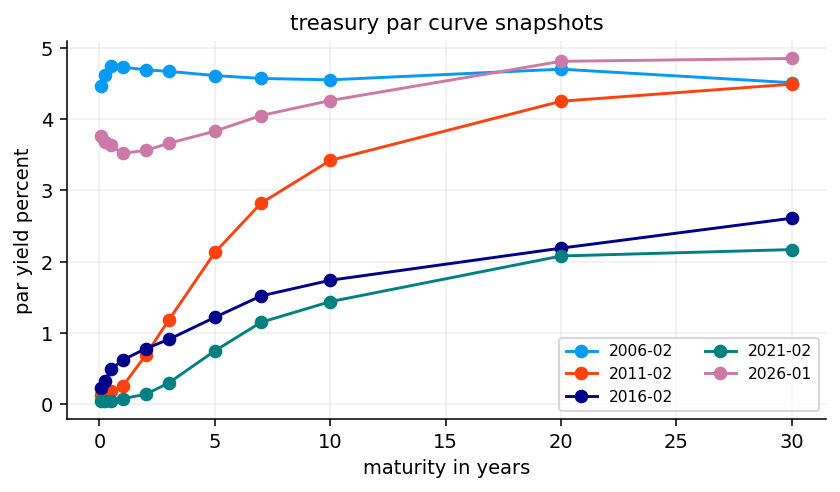

In [6]:
sample_locs = [0, len(curve_dates) // 4, len(curve_dates) // 2, 3 * len(curve_dates) // 4, len(curve_dates) - 1]
sample_dates = [curve_dates[i] for i in sample_locs]
fig, ax = plt.subplots()
for date in sample_dates:
    ax.plot(curve_years, par_yields.loc[date, selected_tenors].to_numpy(float) * 100, marker="o", label=date.strftime("%Y-%m"))
ax.set_title("treasury par curve snapshots")
ax.set_xlabel("maturity in years")
ax.set_ylabel("par yield percent")
ax.legend(ncol=2)
plt.show()


In [7]:
short_tenor = "1M" if "1M" in par_yields.columns else "3M"
short_rate = par_yields[short_tenor].rename("short rate proxy")
selected_yields = pd.DataFrame({
    "2y": zero_rates[2.0],
    "5y": zero_rates[5.0],
    "10y": zero_rates[10.0],
    "30y": zero_rates[30.0],
})
slope_series = pd.DataFrame({
    "2s10s": zero_rates[10.0] - zero_rates[2.0],
    "5s30s": zero_rates[30.0] - zero_rates[5.0],
})
short_and_slopes = pd.concat([short_rate, selected_yields, slope_series], axis=1)
short_and_slopes.tail()


,short rate proxy,2y,5y,10y,30y,2s10s,5s30s
2025-09-30,0.0420,0.035657,0.037122,0.041730,0.048237,0.006073,0.011115
2025-10-31,0.0406,0.035656,0.036813,0.041201,0.047593,0.005545,0.010780
2025-11-30,0.0405,0.034371,0.035628,0.040343,0.047961,0.005972,0.012333
2025-12-31,0.0374,0.034395,0.037074,0.041991,0.049752,0.007596,0.012678
2026-01-31,0.0376,0.035288,0.038062,0.042746,0.049624,0.007459,0.011562


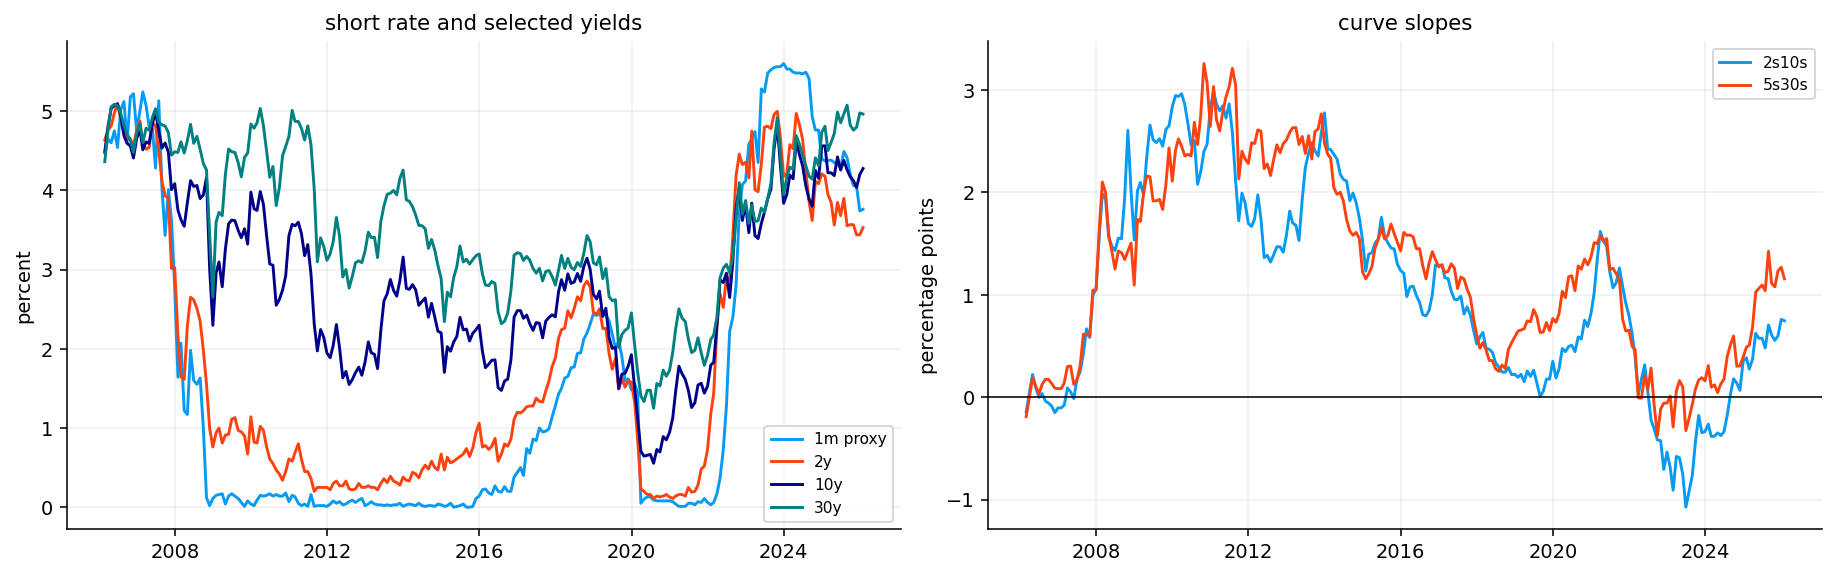

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(short_rate.index, short_rate * 100, label=f"{short_tenor.lower()} proxy")
for col in ["2y", "10y", "30y"]:
    axes[0].plot(selected_yields.index, selected_yields[col] * 100, label=col)
axes[0].set_title("short rate and selected yields")
axes[0].set_ylabel("percent")
axes[0].legend()
for col in slope_series.columns:
    axes[1].plot(slope_series.index, slope_series[col] * 100, label=col)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("curve slopes")
axes[1].set_ylabel("percentage points")
axes[1].legend()
plt.show()


In [9]:
acm_csv_path = root / "data" / "ACMTermPremium.csv"
acm_xls_path = root / "data" / "ACMTermPremium.xls"

def load_acm_10y(csv_path, xls_path):
    if csv_path.exists():
        raw = pd.read_csv(csv_path)
    else:
        try:
            book = pd.ExcelFile(xls_path)
        except ImportError as exc:
            raise ImportError("xlrd >= 2.0.1 is required to read acmtermpremium.xls") from exc
        sheet = next((s for s in book.sheet_names if "monthly" in s.lower()), book.sheet_names[0])
        raw = pd.read_excel(xls_path, sheet_name=sheet, header=0)
    clean = raw.copy()
    clean.columns = [str(c).strip().lower() for c in clean.columns]
    date_col = next((c for c in clean.columns if c in {"date", "dates"} or "date" in c), clean.columns[0])
    tp_col = next((c for c in clean.columns if c.replace("_", "") in {"acmtp10", "tp10"}), None)
    if tp_col is None:
        tp_col = next(c for c in clean.columns if "tp" in c and "10" in c)
    out = clean[[date_col, tp_col]].rename(columns={date_col: "date", tp_col: "acm 10y term premium"})
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out["acm 10y term premium"] = pd.to_numeric(out["acm 10y term premium"], errors="coerce")
    out = out.dropna().drop_duplicates("date").set_index("date").sort_index()
    if out["acm 10y term premium"].abs().median() > 1:
        out["acm 10y term premium"] = out["acm 10y term premium"] / 100
    return out

acm_term_premium = load_acm_10y(acm_csv_path, acm_xls_path)
acm_term_premium.tail()


,acm 10y term premium
date,
2025-12-31,0.007612
2026-01-30,0.007742
2026-02-27,0.006072
2026-03-31,0.006626
2026-04-30,0.007269


In [10]:
acm_10y = acm_term_premium.resample("ME").last().reindex(curve_dates, method="ffill")
term_premium_comparison = acm_10y.copy()
term_premium_summary = pd.DataFrame({
    "item": ["acm source", "first aligned date", "last aligned date", "missing aligned values"],
    "value": ["csv preferred, xls fallback", acm_10y.first_valid_index().date(), acm_10y.last_valid_index().date(), int(acm_10y.isna().sum().iloc[0])],
})
display(term_premium_summary)
term_premium_comparison.tail()


,item,value
0,acm source,"csv preferred, xls fallback"
1,first aligned date,2006-02-28
2,last aligned date,2026-01-31
3,missing aligned values,0


,acm 10y term premium
2025-09-30,0.006215
2025-10-31,0.005737
2025-11-30,0.005939
2025-12-31,0.007612
2026-01-31,0.007742


In [11]:
sofr_path = root / "data" / "sofr.csv"
sofr_start_date = pd.Timestamp("2020-03-02")
sofr_raw = pd.read_csv(sofr_path)
sofr_clean = sofr_raw.copy()
sofr_clean.columns = [str(c).strip().lower().replace(" ", "_") for c in sofr_clean.columns]
sofr_date_col = next(c for c in sofr_clean.columns if "date" in c)
sofr_index_col = next(c for c in sofr_clean.columns if "sofr" in c and "index" in c)
sofr_clean = sofr_clean[[sofr_date_col, sofr_index_col]].rename(columns={sofr_date_col: "date", sofr_index_col: "sofr_index"})
sofr_clean["date"] = pd.to_datetime(sofr_clean["date"], errors="coerce")
sofr_clean["sofr_index"] = pd.to_numeric(sofr_clean["sofr_index"], errors="coerce")
sofr_daily = sofr_clean.dropna().drop_duplicates("date").set_index("date").sort_index()
sofr_daily = sofr_daily.loc[sofr_daily.index >= sofr_start_date]
sofr_monthly_index = sofr_daily["sofr_index"].resample("ME").last()
sofr_cash_return = sofr_monthly_index.pct_change()
first_month = sofr_monthly_index.index.min()
sofr_cash_return.loc[first_month] = sofr_monthly_index.loc[first_month] / sofr_daily["sofr_index"].iloc[0] - 1
sofr_cash_return = sofr_cash_return.reindex(curve_dates).dropna().rename("sofr cash return")
sofr_summary = pd.DataFrame({
    "item": ["source", "first sofr date", "first aligned cash return", "last aligned cash return", "monthly returns"],
    "value": ["data/sofr.csv", sofr_daily.index.min().date(), sofr_cash_return.index.min().date(), sofr_cash_return.index.max().date(), int(sofr_cash_return.notna().sum())],
})
display(sofr_summary)
sofr_cash_return.tail()


,item,value
0,source,data/sofr.csv
1,first sofr date,2020-03-02
2,first aligned cash return,2020-03-31
3,last aligned cash return,2026-01-31
4,monthly returns,71


2025-09-30    0.003832
2025-10-31    0.003620
2025-11-30    0.003109
2025-12-31    0.003500
2026-01-31    0.003066
Name: sofr cash return, dtype: float64

In [12]:
def acf1(values):
    x = pd.Series(values).dropna().astype(float)
    if len(x) < 3 or x.std() == 0:
        return float("nan")
    return float(np.corrcoef(x.iloc[:-1], x.iloc[1:])[0, 1])


def hessian_condition(result):
    try:
        hess_inv = np.asarray(result.hess_inv.todense(), dtype=float)
        return float(np.linalg.cond(hess_inv))
    except Exception:
        return float("nan")


def vasicek_ab(kappa, theta, sigma, tau):
    tau = np.asarray(tau, dtype=float)
    kappa = max(float(kappa), 1e-8)
    b = (1 - np.exp(-kappa * tau)) / kappa
    a = (theta - sigma**2 / (2 * kappa**2)) * (b - tau) - sigma**2 * b**2 / (4 * kappa)
    return a, b


def vasicek_loadings(params, maturities):
    a, b = vasicek_ab(params["kappa"], params["theta"], params["sigma"], maturities)
    maturities = np.asarray(maturities, dtype=float)
    return -a / maturities, b / maturities


def vasicek_yield_loading(params, maturities):
    return vasicek_loadings(params, maturities)[1]


def vasicek_expected_average(r0, params, years=10.0):
    kappa = max(float(params["kappa"]), 1e-8)
    theta = float(params["theta"])
    return theta + (float(r0) - theta) * (1 - np.exp(-kappa * years)) / (kappa * years)


In [13]:
def fit_vasicek_ar(short_history):
    x = pd.Series(short_history).dropna().astype(float)
    if len(x) < 12:
        return {
            "kappa": 0.35,
            "theta": float(x.mean()) if len(x) else 0.03,
            "sigma": 0.01,
            "obs_sd": 0.001,
            "method": "ar fallback",
            "optimizer success": False,
        }
    y = x.iloc[1:].to_numpy()
    lag = x.iloc[:-1].to_numpy()
    slope, intercept = np.polyfit(lag, y, 1)
    phi = float(np.clip(slope, 0.02, 0.995))
    dt = 1 / 12
    kappa = -np.log(phi) / dt
    theta = intercept / max(1 - phi, 1e-6)
    resid = y - (intercept + slope * lag)
    sigma = float(np.std(resid, ddof=1) * np.sqrt(2 * kappa / max(1 - phi**2, 1e-8)))
    return {
        "kappa": kappa,
        "theta": theta,
        "sigma": max(sigma, 1e-5),
        "obs_sd": 0.0015,
        "method": "ar fallback",
        "optimizer success": False,
    }


def vasicek_kalman(yields, maturities, params, state_hint=None):
    data = np.asarray(yields, dtype=float)
    maturities = np.asarray(maturities, dtype=float)
    affine_level, b = vasicek_loadings(params, maturities)
    if state_hint is not None:
        hint = np.asarray(state_hint, dtype=float)
        if len(hint) == len(data):
            a = np.nanmean(data - hint[:, None] * b[None, :], axis=0)
        else:
            a = affine_level
    else:
        a = np.asarray(params.get("obs_alpha", affine_level), dtype=float)
    kappa = max(float(params["kappa"]), 1e-8)
    theta = float(params["theta"])
    sigma = max(float(params["sigma"]), 1e-8)
    obs_sd = max(float(params.get("obs_sd", 0.001)), 1e-8)
    dt = 1 / 12
    phi = np.exp(-kappa * dt)
    q = sigma**2 * (1 - phi**2) / (2 * kappa)
    mean = float(state_hint[0]) if state_hint is not None and len(state_hint) else theta
    var = sigma**2 / (2 * kappa)
    filtered = []
    nll = 0.0
    if np.isfinite(data).all():
        eye = np.eye(data.shape[1])
        outer_b = np.outer(b, b)
        log_const = data.shape[1] * np.log(2 * np.pi)
        for row in data:
            mean_pred = theta + phi * (mean - theta)
            var_pred = phi**2 * var + q
            innov = row - (a + b * mean_pred)
            s = var_pred * outer_b + obs_sd**2 * eye
            sign, logdet = np.linalg.slogdet(s)
            inv_s = np.linalg.pinv(s)
            nll += 0.5 * (logdet + innov @ inv_s @ innov + log_const) if sign > 0 else 1e6
            gain = var_pred * b @ inv_s
            mean = mean_pred + gain @ innov
            var = max(float((1 - gain @ b) * var_pred), 1e-10)
            filtered.append(mean)
        return float(nll), np.asarray(filtered)
    for row in data:
        mean_pred = theta + phi * (mean - theta)
        var_pred = phi**2 * var + q
        mask = np.isfinite(row)
        if mask.any():
            obs = row[mask]
            aa = a[mask]
            bb = b[mask]
            innov = obs - (aa + bb * mean_pred)
            s = var_pred * np.outer(bb, bb) + obs_sd**2 * np.eye(mask.sum())
            sign, logdet = np.linalg.slogdet(s)
            inv_s = np.linalg.pinv(s)
            nll += 0.5 * (logdet + innov @ inv_s @ innov + mask.sum() * np.log(2 * np.pi)) if sign > 0 else 1e6
            gain = var_pred * bb @ inv_s
            mean = mean_pred + gain @ innov
            var = max(float((1 - gain @ bb) * var_pred), 1e-10)
        else:
            mean, var = mean_pred, var_pred
        filtered.append(mean)
    return float(nll), np.asarray(filtered)


In [14]:
def fit_vasicek(yields, maturities, maxiter=80):
    y = pd.DataFrame(yields).dropna(how="all")
    y_values = y.to_numpy(float)
    maturities = np.asarray(maturities, dtype=float)
    short_history = y.iloc[:, 0]
    short_values = y_values[:, 0]
    base = fit_vasicek_ar(short_history)
    x = short_history.to_numpy(float)
    r0 = x[:-1]
    r1 = x[1:]
    dt = 1 / 12

    def objective(z):
        kappa = np.exp(z[0])
        theta = z[1]
        sigma = np.exp(z[2])
        phi = np.exp(-kappa * dt)
        mean = theta + phi * (r0 - theta)
        var = np.maximum(sigma**2 * (1 - phi**2) / (2 * kappa), 1e-12)
        return float(0.5 * np.sum(np.log(2 * np.pi * var) + (r1 - mean) ** 2 / var))

    x0 = np.array([np.log(np.clip(base["kappa"], 0.01, 3.0)), base["theta"], np.log(np.clip(base["sigma"], 0.001, 0.08))])
    bounds = [(np.log(0.01), np.log(5.0)), (-0.05, 0.18), (np.log(0.0005), np.log(0.12))]
    try:
        result = minimize(objective, x0, method="L-BFGS-B", bounds=bounds, options={"maxiter": int(maxiter)})
        if not result.success or not np.isfinite(result.fun):
            raise RuntimeError("vasicek transition optimization failed")
        kappa = float(np.exp(result.x[0]))
        theta = float(result.x[1])
        sigma = float(np.exp(result.x[2]))
        phi = np.exp(-kappa * dt)
        transition_resid = r1 - (theta + phi * (r0 - theta))
        params = {
            "kappa": kappa,
            "theta": theta,
            "sigma": sigma,
            "obs_sd": 0.00075,
            "method": "ou mle + kalman filter",
            "optimizer success": True,
            "hessian condition": hessian_condition(result),
            "residual acf1": acf1(transition_resid),
        }
    except Exception as exc:
        params = {**base, "fit message": str(exc), "hessian condition": np.nan}
    _, filtered = vasicek_kalman(y_values, maturities, params, state_hint=short_values)
    if "residual acf1" not in params:
        params["residual acf1"] = acf1(short_values - filtered)
    return params, pd.Series(filtered, index=y.index, name="filtered short rate")


vasicek_cols = [0.25, 2.0, 5.0, 10.0]
vasicek_fit, vasicek_filtered = fit_vasicek(zero_rates[vasicek_cols], np.array(vasicek_cols))
vasicek_parameter_table = pd.DataFrame([vasicek_fit]).T.rename(columns={0: "vasicek"})
display(vasicek_parameter_table)


,vasicek
kappa,0.098722
theta,0.011937
sigma,0.007334
obs_sd,0.00075
method,ou mle + kalman filter
optimizer success,True
hessian condition,477.005791
residual acf1,0.273378


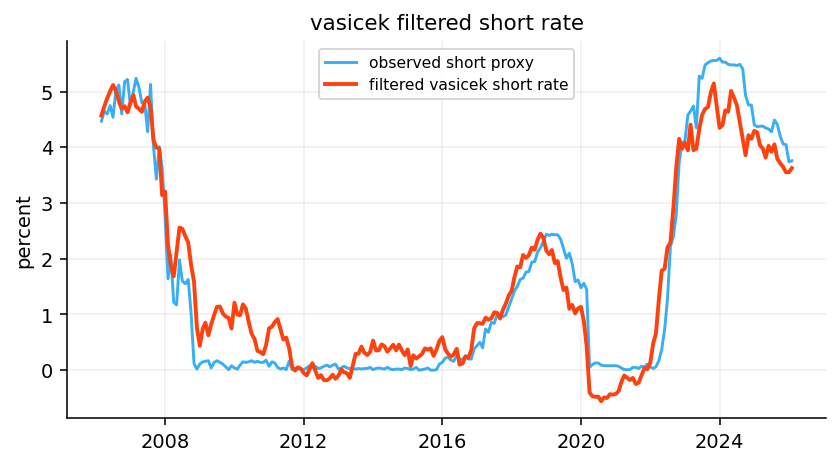

In [15]:
fig, ax = plt.subplots()
ax.plot(short_rate.index, short_rate * 100, label="observed short proxy", alpha=0.8)
ax.plot(vasicek_filtered.index, vasicek_filtered * 100, label="filtered vasicek short rate", linewidth=2)
ax.set_title("vasicek filtered short rate")
ax.set_ylabel("percent")
ax.legend()
plt.show()


In [16]:
def cir_expected_average(r0, params, years=10.0):
    kappa = max(float(params["kappa"]), 1e-8)
    theta = float(params["theta"])
    shift = float(params.get("shift", 0.0))
    shifted_r0 = float(r0) + shift
    avg_shifted = theta + (shifted_r0 - theta) * (1 - np.exp(-kappa * years)) / (kappa * years)
    return avg_shifted - shift


def cir_yield_loading(params, maturities):
    kappa = max(float(params["kappa"]), 1e-6)
    t = np.asarray(maturities, dtype=float)
    return (1 - np.exp(-kappa * t)) / (kappa * np.maximum(t, 1e-8))


def fit_cir(short_history, maxiter=120):
    raw = pd.Series(short_history).dropna().astype(float)
    shift = max(0.0, 0.002 - float(raw.min())) if len(raw) else 0.0
    x = raw + shift
    x_values = x.to_numpy(float)
    r0 = x_values[:-1]
    r1 = x_values[1:]
    r0_floor = np.maximum(r0, 1e-8)
    log_two_pi = np.log(2 * np.pi)
    dt = 1 / 12
    theta_low = max(float(x.mean()) * 0.35, 1e-5)
    theta_high = max(float(x.mean()) * 2.50, theta_low + 0.005)

    def objective(z):
        kappa, theta, sigma = np.exp(z[0]), np.exp(z[1]), np.exp(z[2])
        mean = r0 + kappa * (theta - r0) * dt
        var = np.maximum(sigma**2 * r0_floor * dt, 1e-10)
        nll = 0.5 * np.sum(log_two_pi + np.log(var) + (r1 - mean) ** 2 / var)
        feller_gap = max(0.0, sigma**2 - 2 * kappa * theta)
        return float(nll + 1e7 * feller_gap**2)

    ar = fit_vasicek_ar(raw)
    x0 = np.log([
        np.clip(ar["kappa"], 0.01, 2.0),
        np.clip(raw.mean() + shift, theta_low, theta_high),
        np.clip(ar["sigma"], 0.001, 0.08),
    ])
    bounds = [(np.log(0.005), np.log(4.0)), (np.log(theta_low), np.log(theta_high)), (np.log(0.0005), np.log(0.12))]
    try:
        result = minimize(objective, x0, method="L-BFGS-B", bounds=bounds, options={"maxiter": int(maxiter)})
        if not result.success or not np.isfinite(result.fun):
            raise RuntimeError(str(result.message))
        kappa, theta, sigma = np.exp(result.x)
        method = "quasi mle"
        success = True
        message = str(result.message)
        hcond = hessian_condition(result)
    except Exception as exc:
        kappa = ar["kappa"]
        theta = np.clip(raw.mean() + shift, theta_low, theta_high)
        sigma = max(min(ar["sigma"], 0.08), 0.001)
        method = "bounded ar fallback"
        success = False
        message = str(exc)
        hcond = np.nan
        cir_fit_log.append({"end date": raw.index[-1] if len(raw) else pd.NaT, "message": message})
    resid = r1 - (r0 + kappa * (theta - r0) * dt)
    return {
        "kappa": float(kappa),
        "theta": float(theta),
        "sigma": float(sigma),
        "shift": float(shift),
        "method": method,
        "optimizer success": success,
        "hessian condition": hcond,
        "residual acf1": acf1(resid),
        "theta lower": theta_low,
        "theta upper": theta_high,
        "fit message": message,
    }


cir_fit_log = []


In [17]:
cir_fit = fit_cir(short_rate)
cir_parameter_table = pd.DataFrame([cir_fit])
cir_parameter_table["feller margin"] = 2 * cir_parameter_table["kappa"] * cir_parameter_table["theta"] - cir_parameter_table["sigma"] ** 2
cir_cols = ["kappa", "theta", "sigma", "shift", "feller margin", "optimizer success", "hessian condition", "residual acf1", "method"]
display(cir_parameter_table[cir_cols].T.rename(columns={0: "cir"}))


,cir
kappa,0.129856
theta,0.01548
sigma,0.063476
shift,0.002
feller margin,-0.000009
optimizer success,True
hessian condition,597205.006734
residual acf1,0.039882
method,quasi mle


In [18]:
def simulate_vasicek_paths(r0, params, years=5.0, steps_per_year=12, n_paths=200, seed=9):
    local_rng = np.random.default_rng(seed)
    steps = int(years * steps_per_year)
    dt = 1 / steps_per_year
    paths = np.empty((steps + 1, n_paths))
    paths[0] = float(r0)
    kappa = max(float(params["kappa"]), 1e-8)
    theta = float(params["theta"])
    sigma = max(float(params["sigma"]), 1e-8)
    phi = np.exp(-kappa * dt)
    std = sigma * np.sqrt((1 - phi**2) / (2 * kappa))
    for step in range(1, steps + 1):
        paths[step] = theta + phi * (paths[step - 1] - theta) + std * local_rng.normal(size=n_paths)
    return pd.DataFrame(paths, index=np.arange(steps + 1) / steps_per_year)


def simulate_cir_paths(r0, params, years=5.0, steps_per_year=12, n_paths=200, seed=10):
    local_rng = np.random.default_rng(seed)
    steps = int(years * steps_per_year)
    dt = 1 / steps_per_year
    shift = float(params.get("shift", 0.0))
    paths = np.empty((steps + 1, n_paths))
    paths[0] = max(float(r0) + shift, 1e-8)
    for step in range(1, steps + 1):
        prev = np.maximum(paths[step - 1], 1e-8)
        drift = params["kappa"] * (params["theta"] - prev) * dt
        shock = params["sigma"] * np.sqrt(prev * dt) * local_rng.normal(size=n_paths)
        paths[step] = np.maximum(prev + drift + shock, 1e-8)
    return pd.DataFrame(paths - shift, index=np.arange(steps + 1) / steps_per_year)


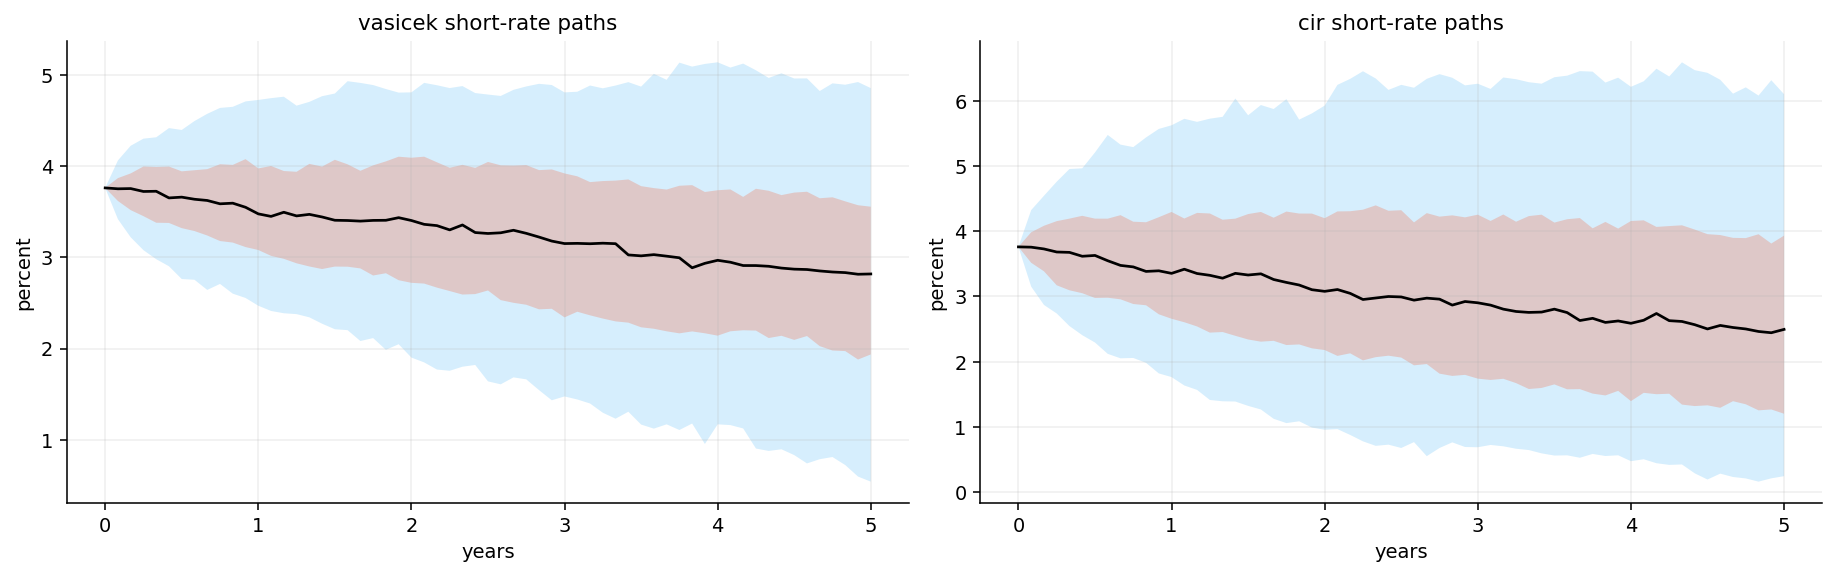

In [19]:
vasicek_paths = simulate_vasicek_paths(short_rate.iloc[-1], vasicek_fit, years=5, n_paths=300, seed=11)
cir_paths = simulate_cir_paths(short_rate.iloc[-1], cir_fit, years=5, n_paths=300, seed=12)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for paths, ax, title in [(vasicek_paths, axes[0], "vasicek short-rate paths"), (cir_paths, axes[1], "cir short-rate paths")]:
    q = paths.quantile([0.05, 0.25, 0.5, 0.75, 0.95], axis=1).T
    ax.fill_between(q.index, q[0.05] * 100, q[0.95] * 100, alpha=0.16)
    ax.fill_between(q.index, q[0.25] * 100, q[0.75] * 100, alpha=0.22)
    ax.plot(q.index, q[0.5] * 100, color="black", linewidth=1.4)
    ax.set_title(title)
    ax.set_xlabel("years")
    ax.set_ylabel("percent")
plt.show()


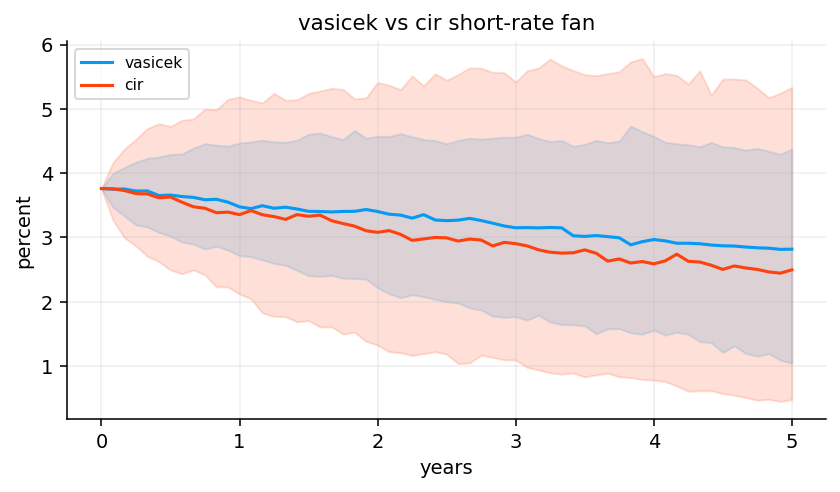

In [20]:
fig, ax = plt.subplots()
for paths, label, color in [(vasicek_paths, "vasicek", colors[0]), (cir_paths, "cir", colors[1])]:
    q = paths.quantile([0.10, 0.50, 0.90], axis=1).T
    ax.fill_between(q.index, q[0.10] * 100, q[0.90] * 100, color=color, alpha=0.16)
    ax.plot(q.index, q[0.50] * 100, color=color, linewidth=1.6, label=label)
ax.set_title("vasicek vs cir short-rate fan")
ax.set_xlabel("years")
ax.set_ylabel("percent")
ax.legend()
plt.show()


In [21]:
rolling_rows = []
for date in curve_dates[rolling_window:]:
    history = zero_rates.loc[:date].tail(rolling_window)
    vfit, _ = fit_vasicek(history[vasicek_cols], np.array(vasicek_cols))
    cfit = fit_cir(short_rate.loc[history.index])
    current_short = float(short_rate.loc[date])
    rolling_rows.append({
        "date": date,
        "vasicek kappa": vfit["kappa"],
        "vasicek theta": vfit["theta"],
        "vasicek sigma": vfit["sigma"],
        "vasicek success": vfit.get("optimizer success", False),
        "vasicek hessian condition": vfit.get("hessian condition", np.nan),
        "vasicek residual acf1": vfit.get("residual acf1", np.nan),
        "cir kappa": cfit["kappa"],
        "cir theta": cfit["theta"],
        "cir sigma": cfit["sigma"],
        "cir shift": cfit["shift"],
        "cir success": cfit.get("optimizer success", False),
        "cir hessian condition": cfit.get("hessian condition", np.nan),
        "cir residual acf1": cfit.get("residual acf1", np.nan),
        "cir feller margin": 2 * cfit["kappa"] * cfit["theta"] - cfit["sigma"] ** 2,
        "vasicek term premium proxy": zero_rates.loc[date, 10.0] - vasicek_expected_average(current_short, vfit),
        "cir term premium proxy": zero_rates.loc[date, 10.0] - cir_expected_average(current_short, cfit),
    })
model_parameters = pd.DataFrame(rolling_rows).set_index("date").sort_index()
term_premium_comparison = term_premium_comparison.join(
    model_parameters[["vasicek term premium proxy", "cir term premium proxy"]],
    how="left")
fit_diagnostics = model_parameters[["vasicek success", "vasicek hessian condition", "vasicek residual acf1", "cir success", "cir hessian condition", "cir residual acf1", "cir feller margin"]]
display(model_parameters.tail())


,vasicek kappa,vasicek theta,vasicek sigma,vasicek success,vasicek hessian condition,vasicek residual acf1,cir kappa,cir theta,cir sigma,cir shift,cir success,cir hessian condition,cir residual acf1,cir feller margin,vasicek term premium proxy,cir term premium proxy
date,,,,,,,,,,,,,,,,
2025-09-30,0.240363,0.065319,0.007570,True,117.046330,0.649488,0.060955,0.082587,0.064139,0.0019,True,667.772433,0.288517,0.005954,-0.014764,-0.009990
2025-10-31,0.264484,0.062020,0.007595,True,117.062833,0.653092,0.062393,0.084246,0.064123,0.0019,True,1412.965005,0.296824,0.006401,-0.013295,-0.010088
2025-11-30,0.283358,0.060569,0.007584,True,117.080011,0.650794,0.064307,0.085900,0.064008,0.0019,True,3946.488790,0.297240,0.006951,-0.013560,-0.011572
2025-12-31,0.314527,0.057336,0.007645,True,117.110842,0.645105,0.066544,0.087425,0.064236,0.0019,True,1100.693681,0.296701,0.007509,-0.009280,-0.008390
2026-01-31,0.341616,0.056278,0.007616,True,117.131658,0.638221,0.071773,0.088962,0.063847,0.0019,True,687.467849,0.292652,0.008694,-0.008244,-0.009022


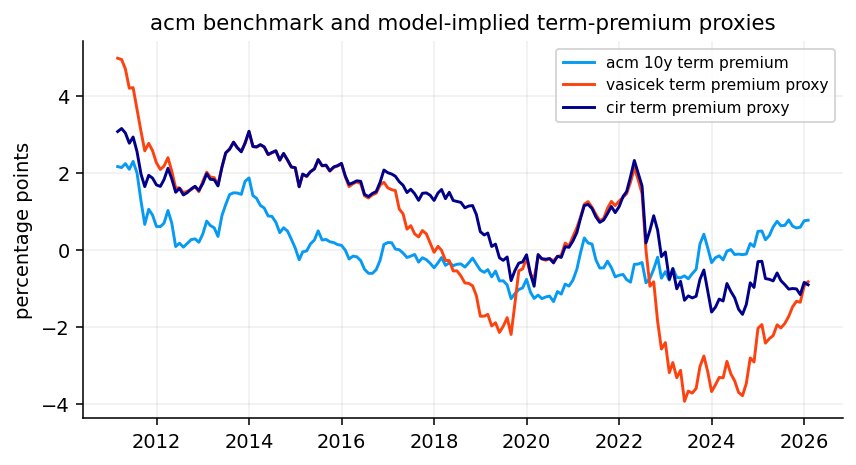

,vasicek term premium proxy,cir term premium proxy
acm 10y term premium,0.541233,0.528921


In [22]:
term_premium_plot = term_premium_comparison.dropna()
term_premium_correlation = term_premium_plot.corr().loc[["acm 10y term premium"], ["vasicek term premium proxy", "cir term premium proxy"]]
fig, ax = plt.subplots()
for col in term_premium_plot.columns:
    ax.plot(term_premium_plot.index, term_premium_plot[col] * 100, label=col)
ax.set_title("acm benchmark and model-implied term-premium proxies")
ax.set_ylabel("percentage points")
ax.legend()
plt.show()
display(term_premium_correlation)


In [23]:
def ar1_expected_score(scores):
    x = pd.Series(scores).dropna().astype(float)
    if len(x) < 12 or x.std() == 0:
        return 0.0, 0.0
    y = x.iloc[1:].to_numpy()
    lag = x.iloc[:-1].to_numpy()
    rho, intercept = np.polyfit(lag, y, 1)
    rho = float(np.clip(rho, -0.35, 0.35))
    return float(intercept + rho * x.iloc[-1]), rho


def estimate_mean_reversion(series):
    x = pd.Series(series).dropna().astype(float)
    if len(x) < 24:
        return 0.25
    y = x.iloc[1:].to_numpy()
    lag = x.iloc[:-1].to_numpy()
    slope, _ = np.polyfit(lag, y, 1)
    phi = np.clip(slope, 0.05, 0.98)
    return float(-np.log(phi) * 12)


def hw1f_loading(a, maturities):
    maturities = np.asarray(maturities, dtype=float)
    a = max(float(a), 1e-6)
    return (1 - np.exp(-a * maturities)) / (a * maturities)


def estimate_hw1f(history, maturities):
    maturities = np.asarray(maturities, dtype=float)
    changes = history[maturities].diff().dropna()
    short_col = 0.25 if 0.25 in history else history.columns[0]
    a = estimate_mean_reversion(history[short_col])
    loading = hw1f_loading(a, maturities)
    factors = changes.to_numpy(float) @ loading / max(float(loading @ loading), 1e-10)
    sigma_month = max(float(np.std(factors, ddof=1)), 1e-6)
    expected_factor, rho = ar1_expected_score(factors)
    fitted = np.outer(factors, loading)
    variance_share = 1 - np.nanvar(changes.to_numpy(float) - fitted) / max(np.nanvar(changes.to_numpy(float)), 1e-12)
    return {
        "a": a,
        "sigma monthly": sigma_month,
        "loading": loading,
        "expected change": expected_factor * loading,
        "factor rho": rho,
        "variance share": float(np.clip(variance_share, 0, 1)),
    }


def simulate_hw1f_curves(base_curve, params, n_scenarios=2000, seed=21):
    local_rng = np.random.default_rng(seed)
    base = np.asarray(base_curve, dtype=float)
    shocks = local_rng.normal(0, params["sigma monthly"], size=n_scenarios)
    return base + params.get("expected change", 0) + shocks[:, None] * params["loading"][None, :]


In [24]:
scenario_maturities = np.array([0.25, 1.0, 2.0, 5.0, 10.0, 30.0], dtype=float)
hw1f_fit = estimate_hw1f(zero_rates.tail(rolling_window), scenario_maturities)
hw1f_diagnostics = pd.DataFrame({
    "metric": ["mean reversion", "monthly factor vol", "annual factor vol", "curve-change variance share"],
    "value": [hw1f_fit["a"], hw1f_fit["sigma monthly"], hw1f_fit["sigma monthly"] * np.sqrt(12), hw1f_fit["variance share"]],
})
display(hw1f_diagnostics)


,metric,value
0,mean reversion,0.341575
1,monthly factor vol,0.003060
2,annual factor vol,0.010599
3,curve-change variance share,0.540349


In [25]:
base_date = curve_dates[-1]
base_curve = zero_rates.loc[base_date, scenario_maturities].to_numpy(float)
hw_curves = simulate_hw1f_curves(base_curve, hw1f_fit, n_scenarios=2000, seed=22)
hw_change_summary = pd.DataFrame(
    np.quantile((hw_curves - base_curve[None, :]) * 10000, [0.10, 0.50, 0.90], axis=0),
    index=["10%", "median", "90%"],
    columns=scenario_maturities,
)
display(hw_change_summary)


,0.25,1.00,2.00,5.00,10.00,30.00
10%,-29.284620,-25.881403,-22.137013,-14.646895,-8.650826,-2.981452
median,7.344197,6.490715,5.551671,3.673248,2.169513,0.747709
90%,44.988080,39.759936,34.007670,22.501083,13.289708,4.580213


In [26]:
def g2_loadings(a, b, maturities):
    first = hw1f_loading(a, maturities)
    second = hw1f_loading(b, maturities)
    second = second - first * float(first @ second) / max(float(first @ first), 1e-10)
    norm = np.sqrt(max(float(second @ second), 1e-10))
    second = second / norm * np.sqrt(max(float(first @ first), 1e-10))
    return np.column_stack([first, second])


def estimate_g2(history, maturities):
    maturities = np.asarray(maturities, dtype=float)
    changes = history[maturities].diff().dropna().to_numpy(float)
    short_col = 0.25 if 0.25 in history else history.columns[0]
    a = estimate_mean_reversion(history[short_col])
    b = max(0.03, min(1.20, a / 4))
    loadings = g2_loadings(a, b, maturities)
    factors = np.linalg.lstsq(loadings, changes.T, rcond=None)[0].T
    cov = np.cov(factors, rowvar=False)
    eig = np.linalg.eigvalsh(cov)
    corr_raw = np.corrcoef(factors.T)[0, 1] if factors.shape[0] > 2 else 0.0
    degenerate = bool(np.min(eig) < 1e-10 or abs(corr_raw) > 0.97)
    if degenerate:
        cov = cov + np.eye(2) * max(float(np.trace(cov)) * 0.03, 1e-8)
    expected = np.array([ar1_expected_score(factors[:, j])[0] for j in range(2)])
    rho = np.array([ar1_expected_score(factors[:, j])[1] for j in range(2)])
    corr = cov[0, 1] / max(np.sqrt(cov[0, 0] * cov[1, 1]), 1e-12)
    return {
        "a": a,
        "b": b,
        "loadings": loadings,
        "factor covariance": cov,
        "expected factors": expected,
        "expected change": loadings @ expected,
        "factor rho": rho,
        "factor correlation": float(corr),
        "degenerate": degenerate,
    }


def simulate_g2_curves(base_curve, params, n_scenarios=2000, seed=31):
    local_rng = np.random.default_rng(seed)
    base = np.asarray(base_curve, dtype=float)
    factors = local_rng.multivariate_normal(np.zeros(2), params["factor covariance"], size=n_scenarios)
    return base + params.get("expected change", 0) + factors @ params["loadings"].T


In [27]:
g2_fit = estimate_g2(zero_rates.tail(rolling_window), scenario_maturities)
g2_cov = g2_fit["factor covariance"]
g2_diagnostics = pd.DataFrame({
    "metric": ["first mean reversion", "second mean reversion", "first monthly vol", "second monthly vol", "factor correlation", "degenerate regularized"],
    "value": [g2_fit["a"], g2_fit["b"], np.sqrt(g2_cov[0, 0]), np.sqrt(g2_cov[1, 1]), g2_fit["factor correlation"], g2_fit["degenerate"]],
})
display(g2_diagnostics)


,metric,value
0,first mean reversion,0.341575
1,second mean reversion,0.085394
2,first monthly vol,0.00306
3,second monthly vol,0.002452
4,factor correlation,0.651594
5,degenerate regularized,False


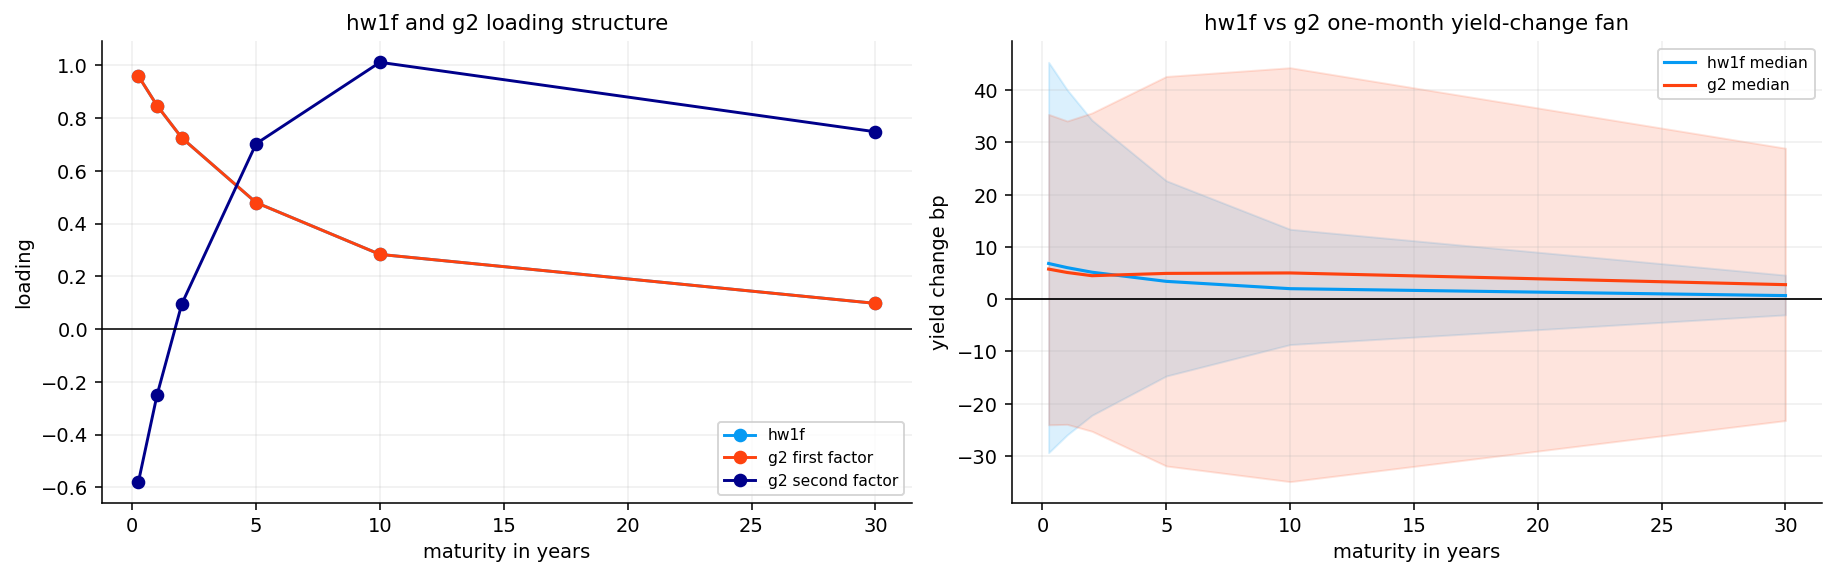

In [28]:
g2_curves = simulate_g2_curves(base_curve, g2_fit, n_scenarios=2000, seed=32)
hw_many = simulate_hw1f_curves(base_curve, hw1f_fit, n_scenarios=2000, seed=33)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot(scenario_maturities, hw1f_fit["loading"], marker="o", label="hw1f")
axes[0].plot(scenario_maturities, g2_fit["loadings"][:, 0], marker="o", label="g2 first factor")
axes[0].plot(scenario_maturities, g2_fit["loadings"][:, 1], marker="o", label="g2 second factor")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("hw1f and g2 loading structure")
axes[0].set_xlabel("maturity in years")
axes[0].set_ylabel("loading")
axes[0].legend()
for scenario_curves, label, color in [(hw_many, "hw1f", colors[0]), (g2_curves, "g2", colors[1])]:
    changes_bp = (scenario_curves - base_curve[None, :]) * 10000
    q = np.quantile(changes_bp, [0.10, 0.50, 0.90], axis=0)
    axes[1].fill_between(scenario_maturities, q[0], q[2], color=color, alpha=0.14)
    axes[1].plot(scenario_maturities, q[1], color=color, linewidth=1.6, label=f"{label} median")
axes[1].axhline(0, color="black", linewidth=0.9)
axes[1].set_title("hw1f vs g2 one-month yield-change fan")
axes[1].set_xlabel("maturity in years")
axes[1].set_ylabel("yield change bp")
axes[1].legend()
plt.show()


In [29]:
def orient_pca_loadings(loadings, scores):
    loadings = loadings.copy()
    scores = scores.copy()
    if loadings[:, 0].mean() < 0:
        loadings[:, 0] *= -1
        scores[:, 0] *= -1
    if loadings[-1, 1] - loadings[0, 1] < 0:
        loadings[:, 1] *= -1
        scores[:, 1] *= -1
    middle = len(loadings) // 2
    if loadings[middle, 2] > 0:
        loadings[:, 2] *= -1
        scores[:, 2] *= -1
    return loadings, scores


def estimate_pca(history, maturities, n_components=3):
    maturities = np.asarray(maturities, dtype=float)
    changes = history[maturities].diff().dropna()
    demeaned = changes - changes.mean()
    fit = PCA(n_components=n_components).fit(demeaned)
    loadings = fit.components_.T
    scores = fit.transform(demeaned)
    loadings, scores = orient_pca_loadings(loadings, scores)
    score_rho = np.array([ar1_expected_score(scores[:, j])[1] for j in range(n_components)])
    return {
        "loadings": loadings,
        "scores": scores,
        "variances": fit.explained_variance_,
        "explained": fit.explained_variance_ratio_,
        "score rho": score_rho,
    }


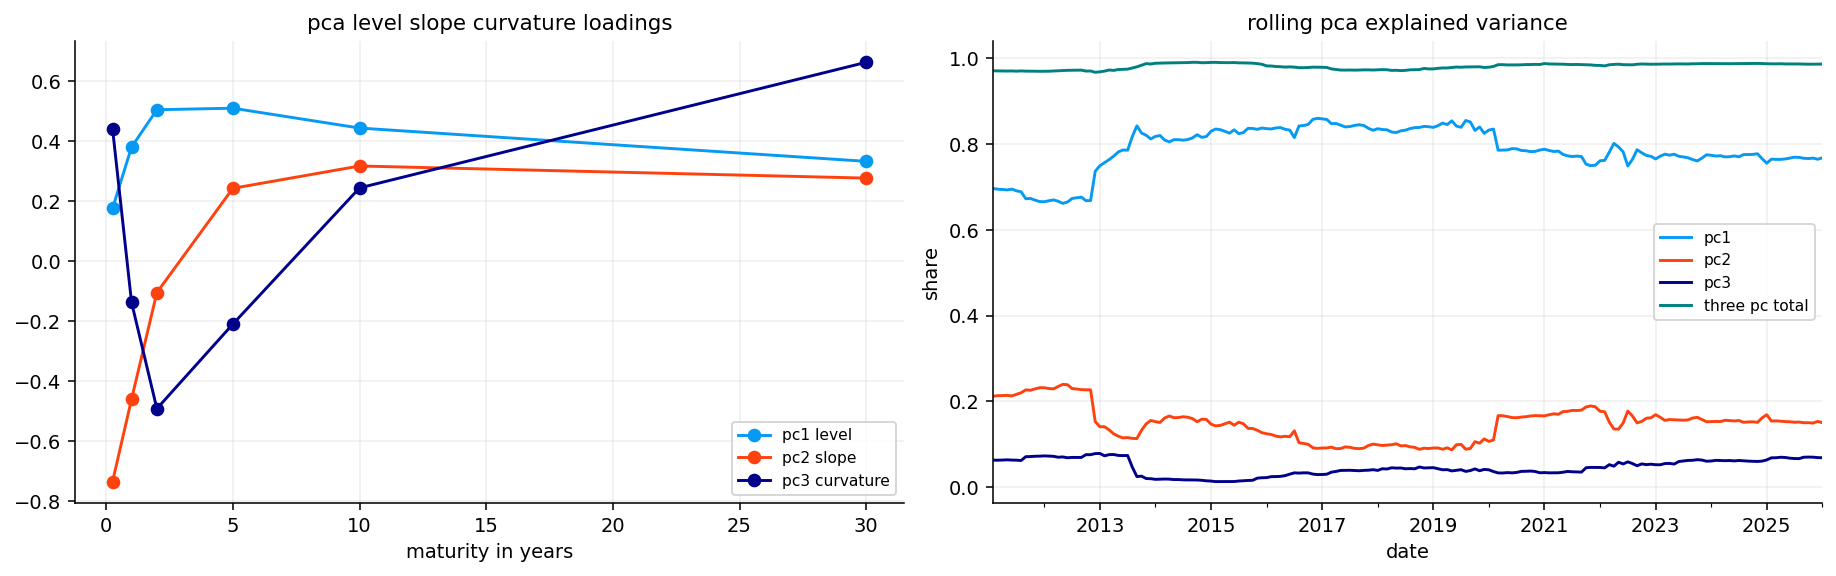

,pc,explained variance,ar1 rho,monthly factor vol
0,pc1 level,0.767778,0.141173,0.005721
1,pc2 slope,0.150263,0.350000,0.002531
2,pc3 curvature,0.068415,-0.026743,0.001708


In [30]:
pca_fit = estimate_pca(zero_rates.tail(rolling_window), scenario_maturities, n_components=3)
pca_diagnostics = pd.DataFrame({
    "pc": ["pc1 level", "pc2 slope", "pc3 curvature"],
    "explained variance": pca_fit["explained"],
    "ar1 rho": pca_fit["score rho"],
    "monthly factor vol": np.sqrt(pca_fit["variances"]),
})
pca_parameter_rows = []
for date in curve_dates[rolling_window:]:
    pfit = estimate_pca(zero_rates.loc[:date].tail(rolling_window), scenario_maturities, n_components=3)
    pca_parameter_rows.append({"date": date, "pc1": pfit["explained"][0], "pc2": pfit["explained"][1], "pc3": pfit["explained"][2], "three pc total": pfit["explained"].sum()})
pca_parameters = pd.DataFrame(pca_parameter_rows).set_index("date")
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for j, label in enumerate(pca_diagnostics["pc"]):
    axes[0].plot(scenario_maturities, pca_fit["loadings"][:, j], marker="o", label=label)
axes[0].set_title("pca level slope curvature loadings")
axes[0].set_xlabel("maturity in years")
axes[0].legend()
pca_parameters.plot(ax=axes[1], title="rolling pca explained variance")
axes[1].set_ylabel("share")
plt.show()
display(pca_diagnostics)


In [31]:
ladder_cost_bps = {2: 2.0, 5: 2.0, 10: 4.0, 30: 6.0}
ladder_buckets = [2, 5, 10, 30]
risk_bucket_bounds = {2: (0.0, 3.5), 5: (3.5, 7.5), 10: (7.5, 20.0), 30: (20.0, 30.0)}
neutral_weights = {2: 0.20, 5: 0.45, 10: 0.25, 30: 0.10}
duration_targets = {"lower duration": 3.0, "neutral duration": 5.0, "higher duration": 7.0}

def run_duration_ladder(name, target_duration=None, target_by_date=None):
    return run_bond_ladder_backtest(
        par_yields=par_yields,
        strategy_name=name,
        curve_method="pchip",
        buckets=ladder_buckets,
        target_weights=neutral_weights,
        trading_cost_bps=ladder_cost_bps,
        duration_target=None if target_duration is None else float(target_duration),
        duration_target_by_date=target_by_date,
        duration_band=0.20,
        cash_tenor_label="3M",
        freq=2,
        short_end="continuous",
        min_block_len=120,
        tenor_cols=selected_tenors,
        risk_bucket_bounds=risk_bucket_bounds,
    )

baseline_ladder = run_duration_ladder("fixed 5y ladder", 5.0)
target_reference_ladders = {name: run_duration_ladder(name, target) for name, target in duration_targets.items()}
baseline_returns = baseline_ladder.returns.rename("fixed 5y ladder")


In [32]:
ladder_rows = []
for name, result in {"fixed 5y ladder": baseline_ladder, **target_reference_ladders}.items():
    risk_df = result.diagnostics["risk"]
    row = {
        "portfolio": name,
        "average duration": risk_df["effective_duration"].mean(),
        "min duration": risk_df["effective_duration"].min(),
        "max duration": risk_df["effective_duration"].max(),
        "average convexity": risk_df["convexity"].mean(),
        "average turnover": result.diagnostics["strategy"]["turnover"].mean(),
        "average cost": result.costs.div(result.nav.shift(1)).replace([np.inf, -np.inf], np.nan).mean(),
    }
    latest_krd = latest_krd_table(result.diagnostics["krd"])
    for _, item in latest_krd.iterrows():
        row[f"krd {int(item['key'])}y"] = item["krd"]
    ladder_rows.append(row)
ladder_comparison = pd.DataFrame(ladder_rows).set_index("portfolio")
display(ladder_comparison)


,average duration,min duration,max duration,average convexity,average turnover,average cost,krd 2y,krd 5y,krd 10y,krd 30y
portfolio,,,,,,,,,,
fixed 5y ladder,4.984305,4.801418,6.139049,42.223659,0.298437,0.000098,0.544558,2.128210,1.523770,0.714312
lower duration,4.289899,3.695161,6.139049,25.132350,0.524000,0.000189,0.612622,2.096555,1.365944,0.000000
neutral duration,4.984305,4.801418,6.139049,42.223659,0.298437,0.000098,0.544558,2.128210,1.523770,0.714312
higher duration,6.984266,6.139049,7.098016,88.444021,0.427938,0.000155,0.304054,2.238605,2.088823,2.383514


In [33]:
def model_curve_view(model_name, date, maturities):
    history = zero_rates.loc[:date].tail(rolling_window)
    maturities = np.asarray(maturities, dtype=float)
    dt = 1 / 12
    if model_name == "cir":
        p = model_parameters.loc[:date].iloc[-1]
        params = {"kappa": p["cir kappa"], "theta": p["cir theta"], "sigma": p["cir sigma"], "shift": p["cir shift"]}
        loading = cir_yield_loading(params, maturities)
        shifted_short = float(short_rate.loc[date]) + params["shift"]
        drift = loading * params["kappa"] * (params["theta"] - shifted_short) * dt
        cov = params["sigma"] ** 2 * max(shifted_short, 1e-6) * dt * np.outer(loading, loading)
        return drift, cov
    if model_name == "hw1f":
        fit = estimate_hw1f(history, scenario_maturities)
        full_cov = fit["sigma monthly"] ** 2 * np.outer(fit["loading"], fit["loading"])
        expected = pd.Series(fit["expected change"], index=scenario_maturities).reindex(maturities).to_numpy(float)
        cov = pd.DataFrame(full_cov, index=scenario_maturities, columns=scenario_maturities).loc[maturities, maturities].to_numpy(float)
        return expected, cov
    if model_name == "g2":
        fit = estimate_g2(history, scenario_maturities)
        full_cov = fit["loadings"] @ fit["factor covariance"] @ fit["loadings"].T
        expected = pd.Series(fit["expected change"], index=scenario_maturities).reindex(maturities).to_numpy(float)
        cov = pd.DataFrame(full_cov, index=scenario_maturities, columns=scenario_maturities).loc[maturities, maturities].to_numpy(float)
        return expected, cov
    p = model_parameters.loc[:date].iloc[-1]
    params = {"kappa": p["vasicek kappa"], "theta": p["vasicek theta"], "sigma": p["vasicek sigma"]}
    loading = vasicek_yield_loading(params, maturities)
    drift = loading * params["kappa"] * (params["theta"] - short_rate.loc[date]) * dt
    cov = params["sigma"] ** 2 * dt * np.outer(loading, loading)
    return drift, cov


In [34]:
def forward_carry_roll_panel(reference_results):
    curve_lookup = make_curve_lookup(par_yields, curve_method="pchip", tenor_cols=selected_tenors, freq=2, short_end="continuous")

    def one_return(result, date):
        loc = curve_dates.get_loc(pd.Timestamp(date))
        if loc >= len(curve_dates) - 1:
            return np.nan
        next_date = curve_dates[loc + 1]
        snapshot = result.diagnostics["snapshots"].get(pd.Timestamp(date))
        curve = curve_lookup(date)
        if snapshot is None or curve is None:
            return np.nan
        positions = clone_positions(snapshot["positions"])
        cash = float(snapshot["cash"])
        df_func = curve.df
        nav_start = cash + sum(position_values_by_bucket(positions, date, df_func, buckets=ladder_buckets).values())
        cash_rate = float(par_yields.loc[pd.Timestamp(date), "3M"]) if "3M" in par_yields else 0.0
        cash_next = cash * math.exp(cash_rate * yearfrac(date, next_date))
        income = 0.0
        for maturity in list(positions):
            gross, _, _ = bond_cashflows_between(positions[maturity], date, next_date)
            income += gross
        value_next = sum(position_values_by_bucket(positions, next_date, df_func, buckets=ladder_buckets).values())
        return (cash_next + income + value_next) / max(nav_start, 1e-12) - 1

    return pd.DataFrame({
        name: pd.Series({date: one_return(result, date) for date in curve_dates[:-1]}, name=name)
        for name, result in reference_results.items()
    })


def target_score_table(date, model_name, target_names, previous_target):
    expected_change, cov = model_curve_view(model_name, date, key_maturities)
    rows = []
    base_krd = reference_krd["neutral duration"].loc[:date].iloc[-1].to_numpy(float)
    for target_name in target_names:
        krd = reference_krd[target_name].loc[:date].iloc[-1].to_numpy(float)
        active_krd = krd - base_krd
        carry_diff = float(reference_carry.loc[date, target_name] - reference_carry.loc[date, "neutral duration"])
        curve_return = -float(active_krd @ expected_change)
        active_risk = float(np.sqrt(max(active_krd @ cov @ active_krd, 1e-12)))
        transition_cost = 0.0 if target_name == previous_target else 0.00020 + 0.00005 * abs(duration_targets[target_name] - duration_targets[previous_target])
        expected_active = carry_diff + curve_return - transition_cost
        score = (expected_active - 0.15 * active_risk) / active_risk
        rows.append({
            "target": target_name,
            "target duration": duration_targets[target_name],
            "expected active return": expected_active,
            "active risk": active_risk,
            "score": score,
            "carry difference": carry_diff,
            "curve view return": curve_return,
            "transition cost": transition_cost,
        })
    out = pd.DataFrame(rows).set_index("target")
    out.insert(0, "date", pd.Timestamp(date))
    out.insert(1, "model", model_name)
    return out


duration_model_names = ["cir", "hw1f", "g2"]
reference_results = {"neutral duration": baseline_ladder, **target_reference_ladders}
reference_krd = {name: krd_pivot(result.diagnostics["krd"]).reindex(columns=ladder_buckets) for name, result in reference_results.items()}
reference_carry = forward_carry_roll_panel(reference_results)
model_target_logs = {}
for model_name in duration_model_names:
    rows = []
    previous_target = "neutral duration"
    for i in range(rolling_window, len(curve_dates) - 1):
        date = curve_dates[i]
        scores = target_score_table(date, model_name, list(duration_targets), previous_target)
        target_name = scores["score"].idxmax() if scores["expected active return"].max() > 0 else "neutral duration"
        selected = scores.loc[target_name].to_dict()
        selected.update({"date": date, "model": model_name, "target": target_name})
        rows.append(selected)
        previous_target = target_name
    model_target_logs[model_name] = pd.DataFrame(rows).set_index("date")
model_target_by_date = pd.DataFrame({name: log["target duration"] for name, log in model_target_logs.items()})
display(model_target_by_date.tail())


,cir,hw1f,g2
date,,,
2025-08-31,7.0,7.0,5.0
2025-09-30,5.0,7.0,3.0
2025-10-31,5.0,7.0,3.0
2025-11-30,5.0,7.0,3.0
2025-12-31,5.0,7.0,3.0


In [35]:
def select_dynamic_duration_targets(model_target_by_date, model_returns, baseline_returns, validation_months=36, neutral_duration=5.0):
    model_index = model_target_by_date.dropna(how="all").index
    rows = []
    for i in range(int(validation_months), len(model_index)):
        decision_date = model_index[i]
        train_end = model_index[i - 1]
        train = model_returns.loc[:train_end].tail(int(validation_months))
        train_base = baseline_returns.reindex(train.index)
        active = train.sub(train_base, axis=0)
        vol = active.std(ddof=1).replace(0, np.nan)
        score = active.mean() / vol
        selected_model = score.idxmax()
        target_duration = float(model_target_by_date.loc[decision_date, selected_model])
        rows.append({
            "date": decision_date,
            "selected model": selected_model,
            "target duration": target_duration,
            "validation score": score.loc[selected_model],
        })
    log = pd.DataFrame(rows).set_index("date") if rows else pd.DataFrame()
    target_by_date = pd.Series(float(neutral_duration), index=model_target_by_date.index, name="dynamic target duration")
    if not log.empty:
        target_by_date.loc[log.index] = log["target duration"]
    return log, target_by_date


model_duration_results = {
    name: run_duration_ladder(f"{name} dynamic duration ladder", target_duration=5.0, target_by_date=targets)
    for name, targets in model_target_by_date.items()
}
model_duration_returns = pd.DataFrame({name: result.returns for name, result in model_duration_results.items()}).dropna(how="all")
dynamic_duration_log, dynamic_target_by_date = select_dynamic_duration_targets(model_target_by_date, model_duration_returns, baseline_returns, validation_months=36)
dynamic_duration_log["target"] = dynamic_duration_log["target duration"].map({v: k for k, v in duration_targets.items()})
dynamic_duration_ladder = run_duration_ladder("model-driven dynamic duration ladder", target_duration=5.0, target_by_date=dynamic_target_by_date.reindex(curve_dates, method="ffill").fillna(5.0))
first_decision_date = dynamic_duration_log.index.min()
first_return_date = curve_dates[curve_dates.get_loc(first_decision_date) + 1]
evaluation_dates = curve_dates[curve_dates >= first_return_date]
dynamic_duration_returns = dynamic_duration_ladder.returns.reindex(evaluation_dates).rename("model-driven dynamic duration ladder")
dynamic_active_returns = dynamic_duration_returns - baseline_returns.reindex(dynamic_duration_returns.index)
model_selection_table = dynamic_duration_log.groupby("selected model").agg(months=("target", "size"), avg_target_duration=("target duration", "mean"), avg_validation_score=("validation score", "mean"))
target_count_table = dynamic_duration_log["target"].value_counts().rename_axis("target").to_frame("months")
display(model_selection_table)
display(target_count_table)


,months,avg_target_duration,avg_validation_score
selected model,,,
cir,84,6.833333,0.140363
g2,13,5.923077,0.150765
hw1f,46,5.260870,0.108684


,months
target,
higher duration,100
neutral duration,32
lower duration,11


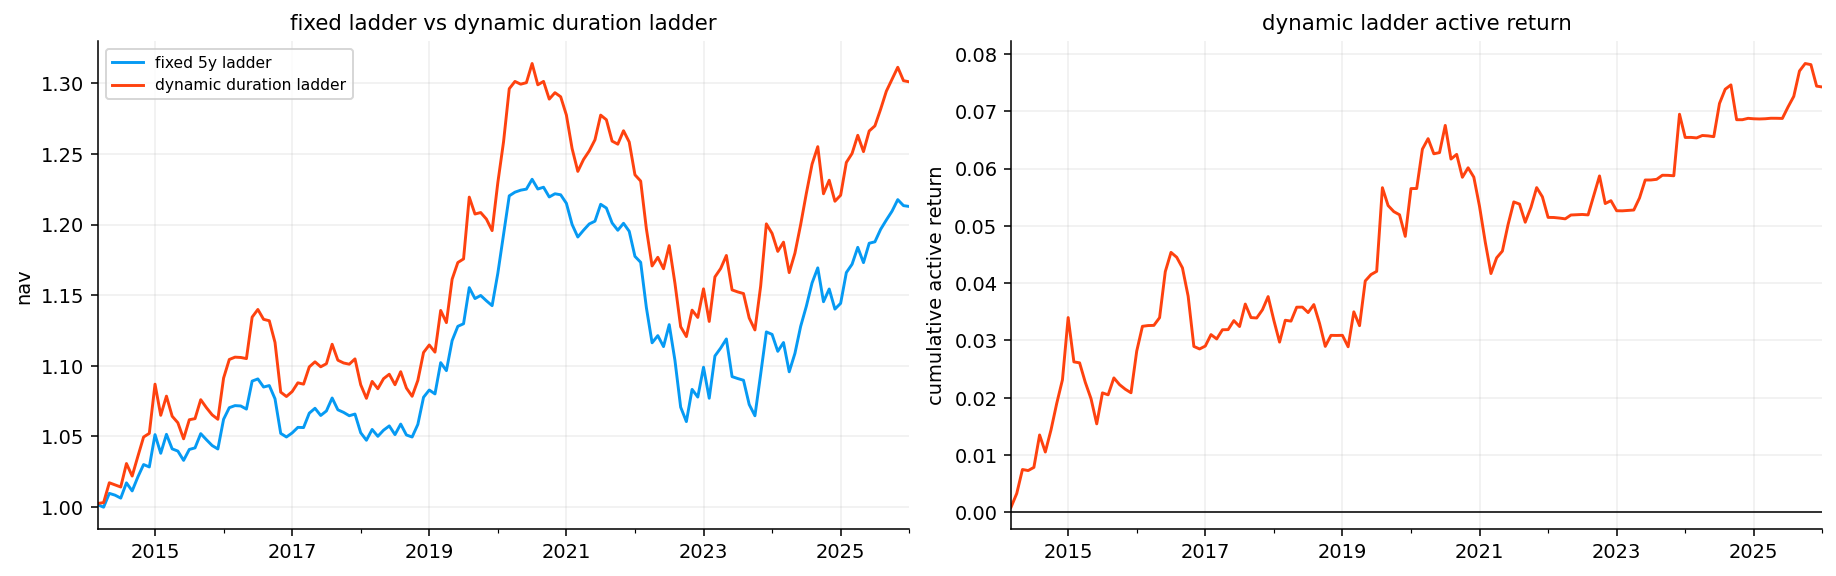

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
nav_series(baseline_returns.reindex(dynamic_duration_returns.index).dropna(), start_value=1).plot(ax=axes[0], label="fixed 5y ladder")
nav_series(dynamic_duration_returns.dropna(), start_value=1).plot(ax=axes[0], label="dynamic duration ladder")
axes[0].set_title("fixed ladder vs dynamic duration ladder")
axes[0].set_ylabel("nav")
axes[0].legend()
dynamic_active_returns.dropna().cumsum().plot(ax=axes[1], color=colors[1])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("dynamic ladder active return")
axes[1].set_ylabel("cumulative active return")
plt.show()


In [37]:
def strategy_summary(returns):
    clean = pd.DataFrame(returns).dropna(how="all")
    perf = performance_table(clean, annualization=12)
    dd = drawdown_summary_table(clean)[["max_dd", "ulcer_index"]]
    return perf.join(dd)


def excess_over_sofr(returns):
    data = pd.DataFrame(returns).copy()
    idx = data.index.intersection(sofr_cash_return.dropna().index)
    return data.loc[idx].sub(sofr_cash_return.loc[idx], axis=0)


def active_versus_baseline(returns):
    data = pd.DataFrame(returns).copy()
    base = baseline_returns.reindex(data.index)
    return data.sub(base, axis=0)

long_return_panel = pd.concat([
    baseline_returns.rename("fixed 5y ladder"),
    dynamic_duration_returns,
], axis=1).dropna()
long_active_panel = active_versus_baseline(long_return_panel[["model-driven dynamic duration ladder"]]).dropna()
long_raw_summary = strategy_summary(long_return_panel)
long_active_summary = strategy_summary(long_active_panel)
display(long_raw_summary)
display(long_active_summary)


,ann_return,ann_vol,sharpe,sortino,max_dd,ulcer_index
object,,,,,,
fixed 5y ladder,0.016327,0.039125,0.433621,0.683569,-0.139352,0.053233
model-driven dynamic duration ladder,0.022339,0.046781,0.495839,0.820428,-0.147225,0.059536


,ann_return,ann_vol,sharpe,sortino,max_dd,ulcer_index
object,,,,,,
model-driven dynamic duration ladder,0.006174,0.012247,0.508743,0.883378,-0.025606,0.010477


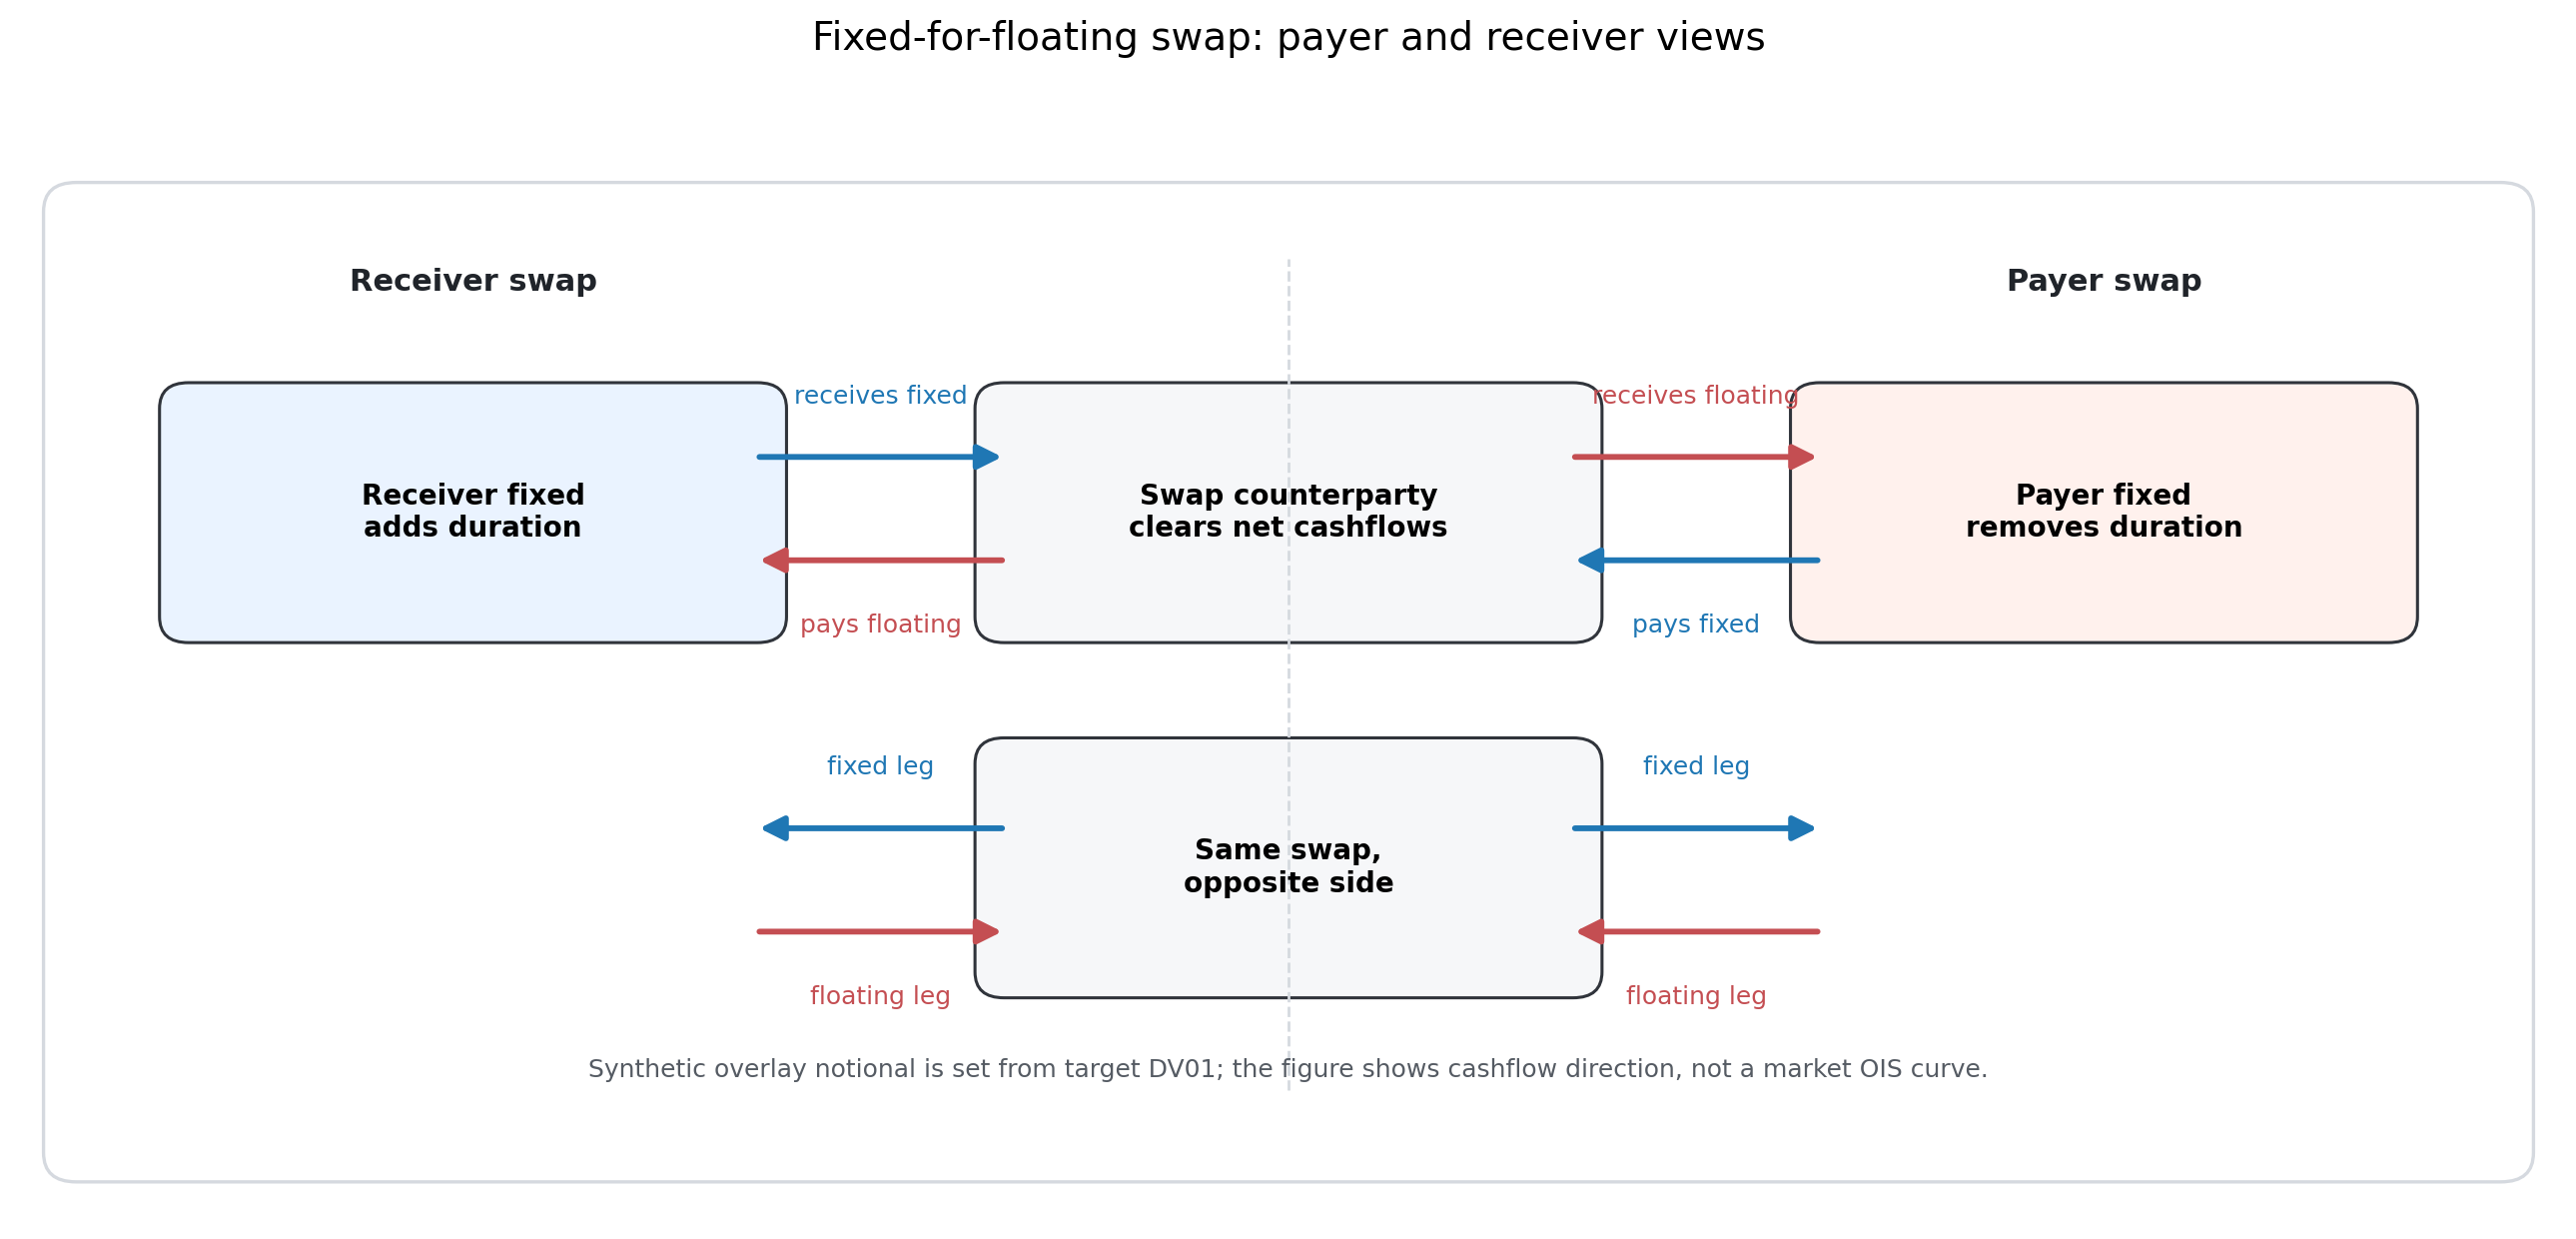

In [38]:
fig, ax = plot_fixed_float_swap_diagram()
plt.show()


In [39]:
def zero_rate_at(date, times, shift=0.0):
    grid = zero_rates.columns.to_numpy(float)
    values = zero_rates.loc[pd.Timestamp(date)].to_numpy(float)
    return np.interp(np.asarray(times, dtype=float), grid, values, left=values[0], right=values[-1]) + float(shift)


def discount_at(date, times, shift=0.0):
    t = np.asarray(times, dtype=float)
    return np.exp(-zero_rate_at(date, t, shift=shift) * t)


def swap_schedule(remaining_tenor, fixed_freq=2):
    step = 1 / int(fixed_freq)
    remaining = max(float(remaining_tenor), step)
    times = np.arange(step, remaining + 1e-10, step)
    if len(times) == 0 or abs(times[-1] - remaining) > 1e-8:
        times = np.r_[times, remaining]
    accruals = np.diff(np.r_[0.0, times])
    return times, accruals


def swap_annuity(date, tenor, shift=0.0, fixed_freq=2):
    times, accruals = swap_schedule(tenor, fixed_freq=fixed_freq)
    return float(np.sum(accruals * discount_at(date, times, shift=shift)))


def par_swap_rate(date, tenor, fixed_freq=2):
    annuity = swap_annuity(date, tenor, fixed_freq=fixed_freq)
    maturity_df = float(discount_at(date, [tenor])[0])
    return (1.0 - maturity_df) / max(annuity, 1e-12)


def swap_value(date, remaining_tenor, fixed_rate, notional=1.0, side="receiver", shift=0.0, fixed_freq=2):
    annuity = swap_annuity(date, remaining_tenor, shift=shift, fixed_freq=fixed_freq)
    maturity_df = float(discount_at(date, [remaining_tenor], shift=shift)[0])
    fixed_value = float(fixed_rate) * annuity * float(notional)
    floating_value = (1.0 - maturity_df) * float(notional)
    receiver_value = fixed_value - floating_value
    return receiver_value if str(side).lower() == "receiver" else -receiver_value


def swap_pv01(date, tenor, side="receiver", bump=1e-4):
    fixed_rate = par_swap_rate(date, tenor)
    pv_up = swap_value(date, tenor, fixed_rate, side=side, shift=bump)
    pv_down = swap_value(date, tenor, fixed_rate, side=side, shift=-bump)
    return float((pv_down - pv_up) / 2)


In [40]:
overlay_tenor = 10.0
overlay_slippage_bp = 0.5
overlay_duration_budget = 1.5
overlay_dv01_fraction_cap = 0.40
example_swap = pd.DataFrame([
    {"side": side, "par rate": par_swap_rate(curve_dates[-1], overlay_tenor), "annuity": swap_annuity(curve_dates[-1], overlay_tenor), "pv01 per 1 notional": swap_pv01(curve_dates[-1], overlay_tenor, side=side)}
    for side in ["receiver", "payer"]
])
display(example_swap)


,side,par rate,annuity,pv01 per 1 notional
0,receiver,0.042576,8.169869,0.000822
1,payer,0.042576,8.169869,-0.000822


In [41]:
def swap_overlay_signal(target_duration, neutral_duration=5.0, neutral_band=0.5):
    target = float(target_duration)
    if target > neutral_duration + neutral_band:
        return 1
    if target < neutral_duration - neutral_band:
        return -1
    return 0


def swap_overlay_target(date, signal, nav, base_duration):
    if int(signal) == 0:
        return {"side": "flat", "notional": 0.0, "fixed rate": np.nan, "pv01": 0.0, "base duration": base_duration}
    base_dv01 = float(base_duration) * float(nav) * 1e-4
    target_pv01 = int(signal) * min(overlay_duration_budget * float(nav) * 1e-4, overlay_dv01_fraction_cap * abs(base_dv01))
    side = "receiver" if target_pv01 > 0 else "payer"
    pv01_unit = swap_pv01(date, overlay_tenor, side=side)
    notional = abs(target_pv01 / max(abs(pv01_unit), 1e-12))
    return {"side": side, "notional": notional, "fixed rate": par_swap_rate(date, overlay_tenor), "pv01": pv01_unit * notional, "base duration": base_duration}


def run_swap_overlay(target_log, start_date):
    base_returns = baseline_ladder.returns
    base_duration = baseline_ladder.diagnostics["risk"]["effective_duration"]
    rows = []
    nav = 1.0
    previous_signed_notional = 0.0
    first_date = pd.Timestamp(start_date)
    for date, row in target_log.iterrows():
        decision_date = pd.Timestamp(date)
        if decision_date not in curve_dates:
            continue
        loc = curve_dates.get_loc(decision_date)
        if loc >= len(curve_dates) - 1:
            continue
        next_date = curve_dates[loc + 1]
        if next_date < first_date or next_date not in base_returns.index:
            continue
        nav_start = nav
        signal = swap_overlay_signal(row["target duration"])
        target = swap_overlay_target(decision_date, signal, nav_start, float(base_duration.loc[:decision_date].iloc[-1]))
        side = target["side"]
        notional = float(target["notional"])
        signed_notional = notional if side == "receiver" else -notional if side == "payer" else 0.0
        annuity = swap_annuity(decision_date, overlay_tenor)
        cost = abs(signed_notional - previous_signed_notional) * annuity * overlay_slippage_bp / 10000
        if side == "flat":
            overlay_pnl = 0.0
        else:
            holding_years = max((next_date - decision_date).days / 365.25, 1 / 365.25)
            remaining_tenor = max(overlay_tenor - holding_years, 0.25)
            overlay_pnl = swap_value(next_date, remaining_tenor, target["fixed rate"], notional=notional, side=side)
        overlay_return = overlay_pnl / max(nav_start, 1e-12)
        cost_return = cost / max(nav_start, 1e-12)
        component_return = overlay_return - cost_return
        nav = nav_start * (1 + float(base_returns.loc[next_date]) + component_return)
        rows.append({
            "date": next_date,
            "decision date": decision_date,
            "label": "Treasury-implied synthetic swap overlay",
            "side": side,
            "signal": signal,
            "notional": notional,
            "signed notional": signed_notional,
            "fixed rate": target["fixed rate"],
            "overlay pv01": target["pv01"],
            "base duration": target["base duration"],
            "target duration": row["target duration"],
            "core return": float(base_returns.loc[next_date]),
            "overlay return": overlay_return,
            "cost return": cost_return,
            "overlay component return": component_return,
            "total return": float(base_returns.loc[next_date]) + component_return,
            "nav with base": nav,
        })
        previous_signed_notional = signed_notional
    log = pd.DataFrame(rows).set_index("date") if rows else pd.DataFrame()
    overlay_returns = log["overlay component return"].rename("Treasury-implied synthetic swap overlay") if not log.empty else pd.Series(dtype=float, name="Treasury-implied synthetic swap overlay")
    return log, overlay_returns


swap_overlay_log, swap_component_returns = run_swap_overlay(dynamic_duration_log, sofr_cash_return.index.min())
swap_overlay_result = combine_ladder_with_return_overlay(
    baseline_ladder,
    swap_component_returns,
    strategy_name="5y ladder plus synthetic swap overlay",
    overlay_costs=swap_overlay_log["cost return"],
    diagnostics={"overlay log": swap_overlay_log},
)
swap_overlay_returns = swap_overlay_result.returns
swap_overlay_log.tail()


,decision date,label,side,signal,notional,signed notional,fixed rate,overlay pv01,base duration,target duration,core return,overlay return,cost return,overlay component return,total return,nav with base
date,,,,,,,,,,,,,,,,
2025-09-30,2025-08-31,Treasury-implied synthetic swap overlay,receiver,1,0.184032,0.184032,0.042273,0.000151,4.998695,7.0,0.005537,0.001128,3.134262e-07,0.001127,0.006664,1.016676
2025-10-31,2025-09-30,Treasury-implied synthetic swap overlay,receiver,1,0.184591,0.184591,0.041578,0.000153,4.970516,7.0,0.005217,0.000832,2.255035e-07,0.000832,0.006049,1.022826
2025-11-30,2025-10-31,Treasury-implied synthetic swap overlay,receiver,1,0.185272,0.185272,0.041080,0.000153,4.905310,7.0,0.006744,0.001438,2.736752e-07,0.001437,0.008181,1.031194
2025-12-31,2025-11-30,Treasury-implied synthetic swap overlay,receiver,1,0.186078,0.186078,0.040179,0.000155,4.995562,7.0,-0.003488,-0.002247,3.229944e-07,-0.002247,-0.005734,1.025281
2026-01-31,2025-12-31,Treasury-implied synthetic swap overlay,receiver,1,0.186385,0.186385,0.041775,0.000154,4.996026,7.0,-0.000480,-0.001093,1.227290e-07,-0.001093,-0.001572,1.023668


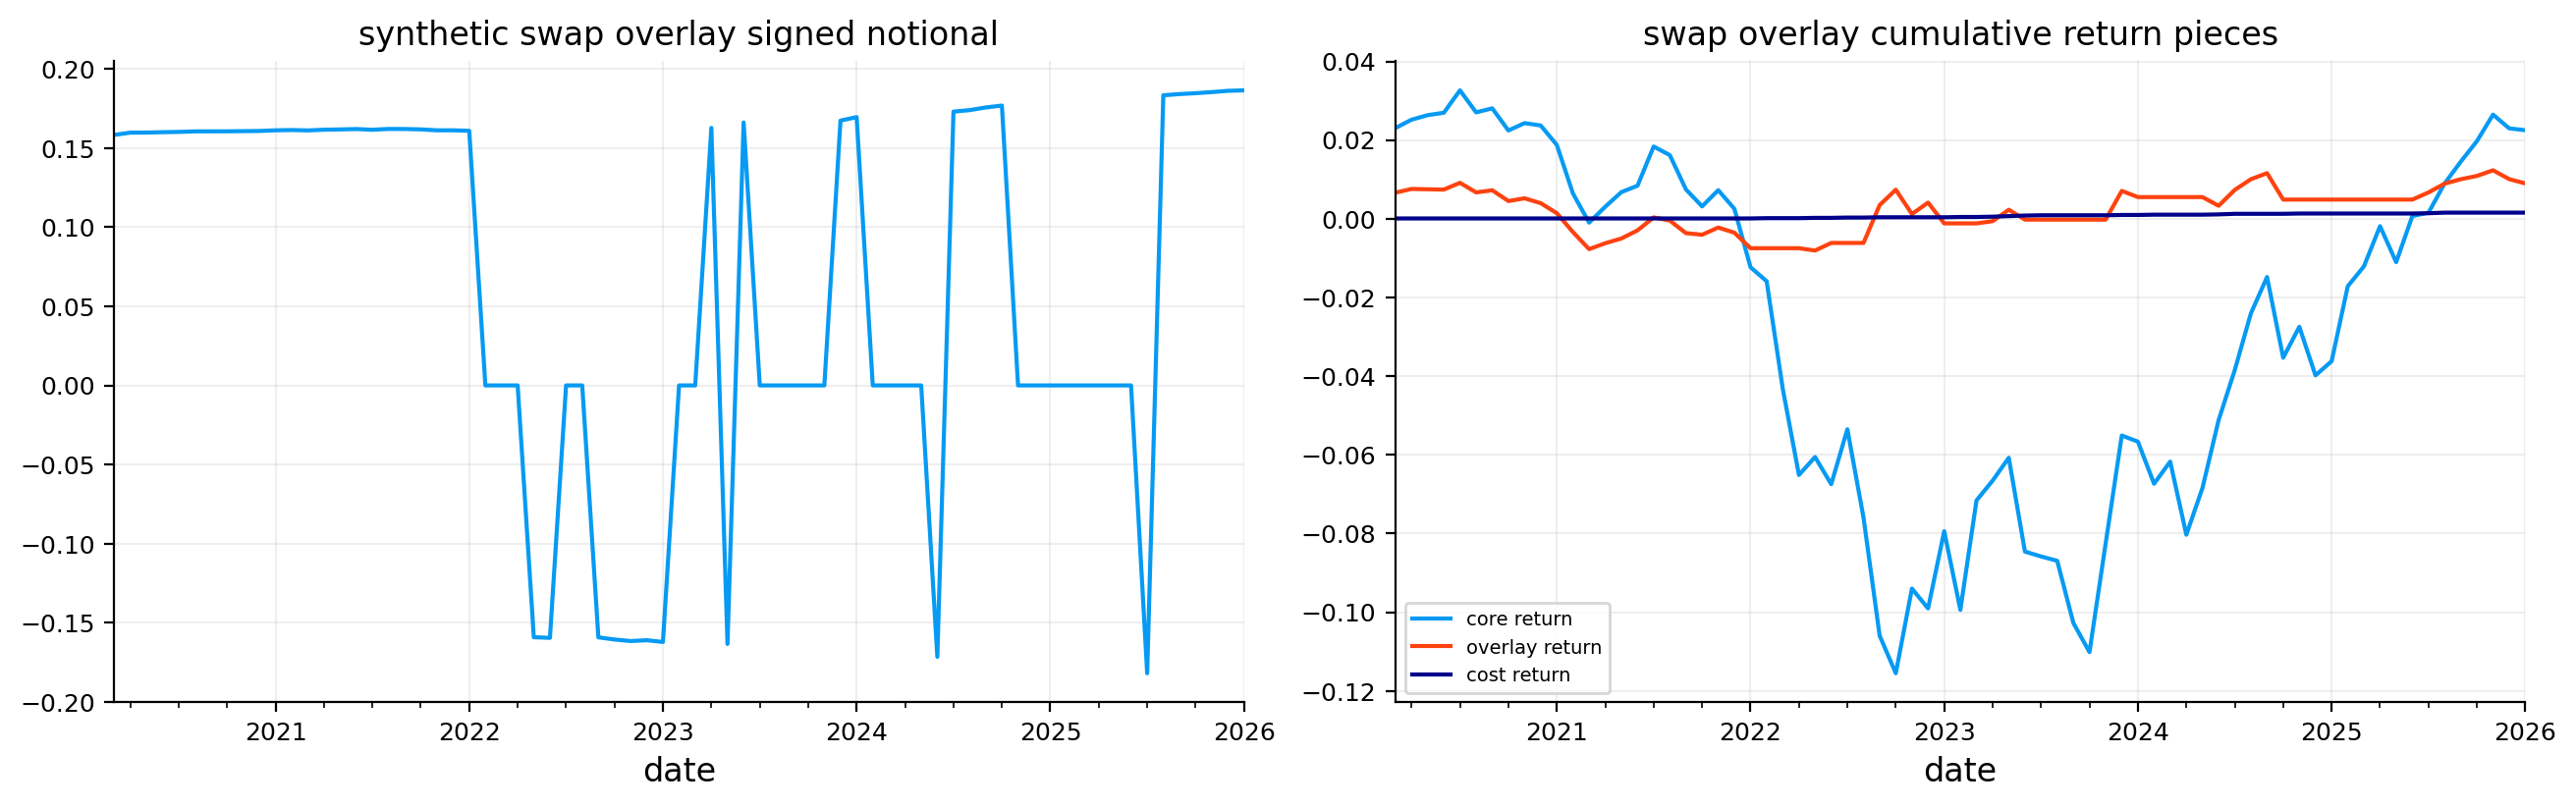

,item,value
0,first overlay return,2020-03-31
1,last overlay return,2026-01-31
2,active months,47
3,average abs notional,0.110039
4,average cost return,0.000022


In [42]:
swap_overlay_summary = pd.DataFrame({
    "item": ["first overlay return", "last overlay return", "active months", "average abs notional", "average cost return"],
    "value": [
        swap_overlay_returns.first_valid_index().date(),
        swap_overlay_returns.last_valid_index().date(),
        int((swap_overlay_log["side"] != "flat").sum()),
        swap_overlay_log["notional"].abs().mean(),
        swap_overlay_log["cost return"].mean(),
    ],
})
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
swap_overlay_log["signed notional"].plot(ax=axes[0], title="synthetic swap overlay signed notional")
swap_overlay_log[["core return", "overlay return", "cost return"]].cumsum().plot(ax=axes[1], title="swap overlay cumulative return pieces")
plt.show()
display(swap_overlay_summary)


In [43]:
portfolio_returns = pd.concat([
    baseline_returns.rename("fixed 5y ladder"),
    dynamic_duration_returns,
    swap_overlay_returns,
], axis=1)
modern_index = portfolio_returns.dropna(how="all").index.intersection(sofr_cash_return.dropna().index)
modern_returns = portfolio_returns.loc[modern_index].dropna(how="all")
modern_excess_returns = excess_over_sofr(modern_returns)
modern_active_returns = active_versus_baseline(modern_returns[["model-driven dynamic duration ladder", "5y ladder plus synthetic swap overlay"]]).dropna(how="all")
raw_performance = strategy_summary(modern_returns)
sofr_excess_performance = strategy_summary(modern_excess_returns)
active_performance = strategy_summary(modern_active_returns)
display(raw_performance)
display(sofr_excess_performance)
display(active_performance)


,ann_return,ann_vol,sharpe,sortino,max_dd,ulcer_index
object,,,,,,
5y ladder plus synthetic swap overlay,0.003962,0.047298,0.106909,0.154856,-0.144692,0.079719
fixed 5y ladder,0.002811,0.044921,0.084642,0.120887,-0.139352,0.073189
model-driven dynamic duration ladder,0.005632,0.048955,0.138857,0.204679,-0.147225,0.079840


,ann_return,ann_vol,sharpe,sortino,max_dd,ulcer_index
object,,,,,,
5y ladder plus synthetic swap overlay,-0.024043,0.046375,-0.501316,-0.625216,-0.194012,0.129811
fixed 5y ladder,-0.025168,0.044053,-0.556216,-0.679463,-0.185831,0.124697
model-driven dynamic duration ladder,-0.022411,0.047979,-0.448267,-0.570558,-0.193021,0.128420


,ann_return,ann_vol,sharpe,sortino,max_dd,ulcer_index
object,,,,,,
5y ladder plus synthetic swap overlay,0.001212,0.009334,0.134389,0.203758,-0.017266,0.009183
model-driven dynamic duration ladder,0.002946,0.010435,0.287065,0.439489,-0.025606,0.011013


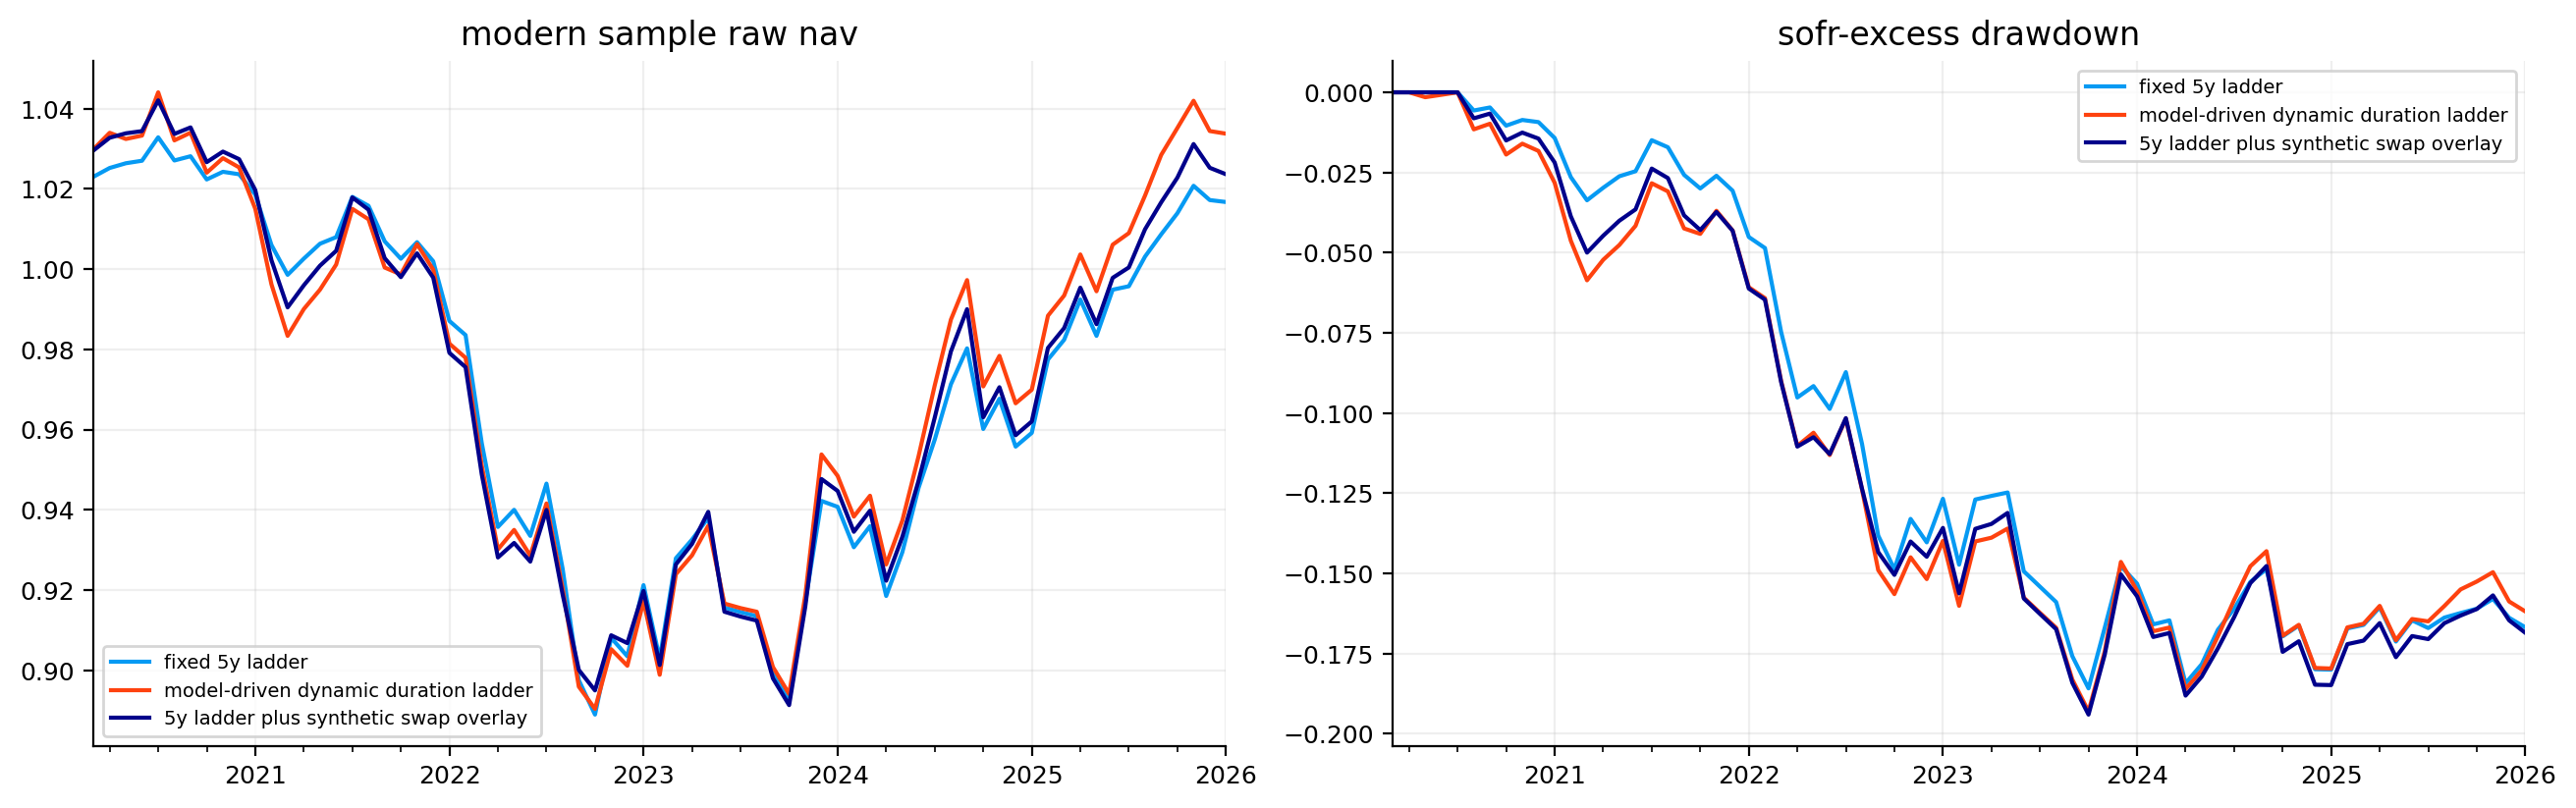

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
for col in modern_returns.columns:
    nav_series(modern_returns[col].dropna(), start_value=1).plot(ax=axes[0], label=col)
axes[0].set_title("modern sample raw nav")
axes[0].legend()
for col in modern_excess_returns.columns:
    drawdown_series(modern_excess_returns[col].dropna(), input_kind="returns").plot(ax=axes[1], label=col)
axes[1].set_title("sofr-excess drawdown")
axes[1].legend()
plt.show()


In [45]:
var_es_raw = var_es_table(modern_returns, alpha=0.05, methods=("hist", "cf"))
var_es_excess = var_es_table(modern_excess_returns, alpha=0.05, methods=("hist", "cf"))
cost_turnover = pd.DataFrame({
    "average turnover": [
        baseline_ladder.diagnostics["strategy"]["turnover"].reindex(modern_index).mean(),
        dynamic_duration_log["target"].ne(dynamic_duration_log["target"].shift()).reindex(modern_index).fillna(False).mean(),
        swap_overlay_log["signed notional"].diff().abs().reindex(modern_index).mean(),
    ],
    "average cost return": [
        baseline_ladder.costs.div(baseline_ladder.nav.shift(1)).reindex(modern_index).mean(),
        np.nan,
        swap_overlay_result.costs.reindex(modern_index).mean(),
    ],
}, index=["fixed 5y ladder", "model-driven dynamic duration ladder", "5y ladder plus synthetic swap overlay"])
display(var_es_raw)
display(var_es_excess)
display(cost_turnover)


,hist_var5,hist_es5,cf_var5,cf_es5
object,,,,
5y ladder plus synthetic swap overlay,0.022143,0.025883,0.021923,0.027430
fixed 5y ladder,0.022143,0.025919,0.021315,0.026990
model-driven dynamic duration ladder,0.022250,0.025793,0.022297,0.027543


,hist_var5,hist_es5,cf_var5,cf_es5
object,,,,
5y ladder plus synthetic swap overlay,0.024064,0.028540,0.024228,0.030223
fixed 5y ladder,0.024608,0.028086,0.023743,0.029698
model-driven dynamic duration ladder,0.024768,0.027989,0.024516,0.030017


,average turnover,average cost return
fixed 5y ladder,0.328333,0.000109
model-driven dynamic duration ladder,0.225352,NaN
5y ladder plus synthetic swap overlay,0.048296,0.000022


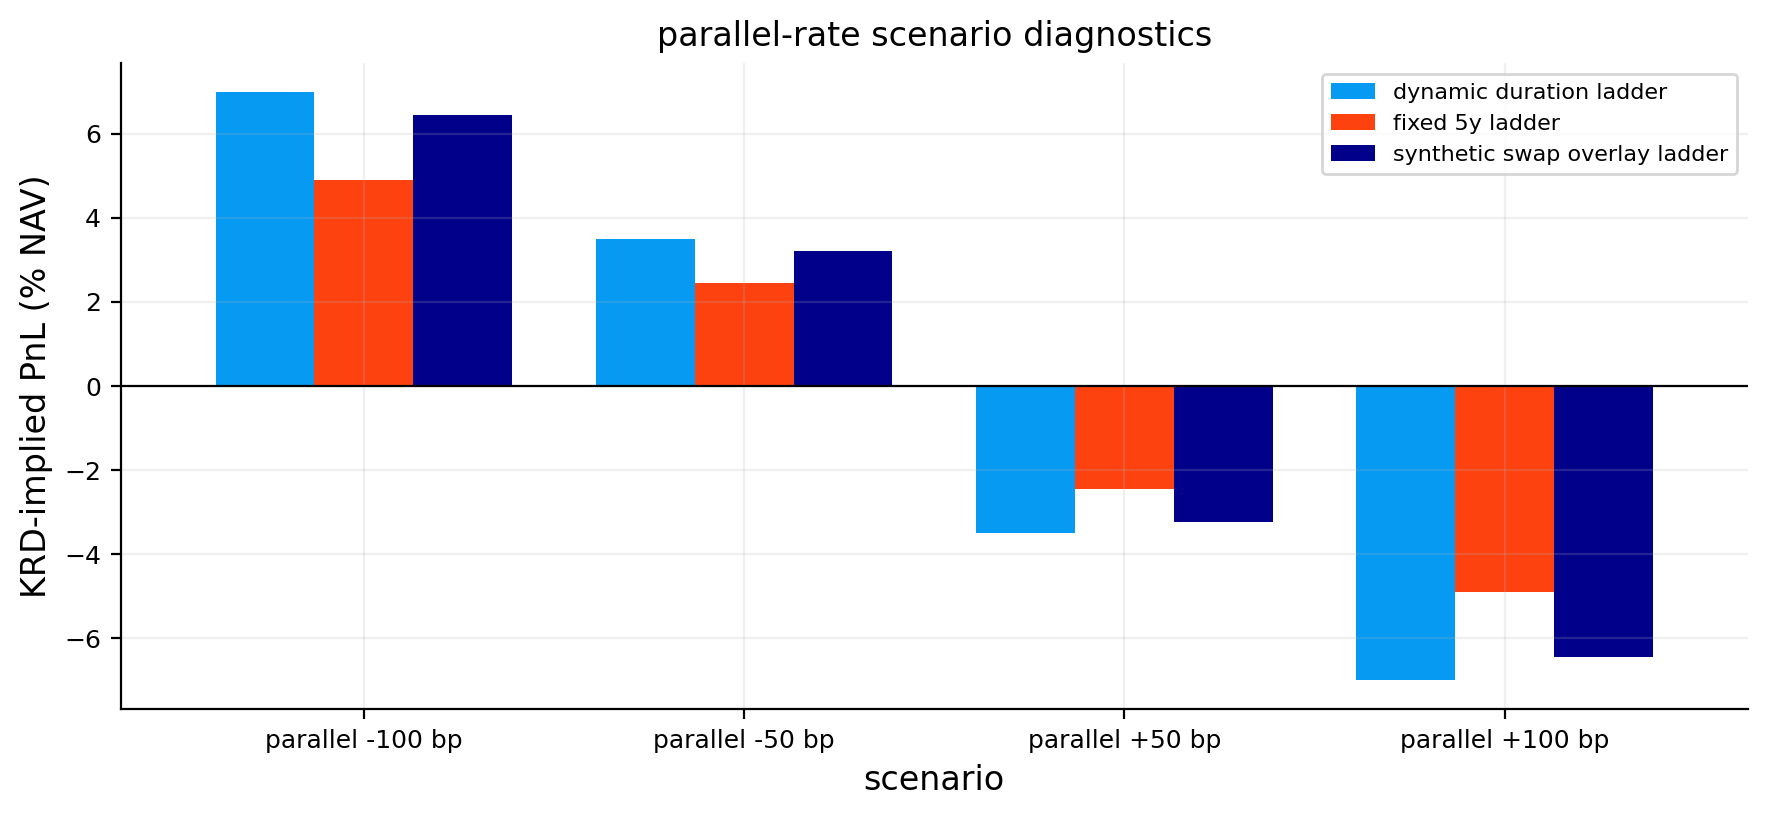

portfolio,dynamic duration ladder,fixed 5y ladder,synthetic swap overlay ladder
scenario,,,
parallel -100 bp,0.069942,0.049109,0.064488
parallel -50 bp,0.034971,0.024554,0.032244
parallel +50 bp,-0.034971,-0.024554,-0.032244
parallel +100 bp,-0.069942,-0.049109,-0.064488


In [46]:
def parallel_shift_scenarios_local(shock_bps, maturities):
    rows = []
    for shock in shock_bps:
        rows.append({"scenario": f"parallel {shock:+.0f} bp", **{m: shock / 10000 for m in maturities}})
    return pd.DataFrame(rows).set_index("scenario")


def krd_scenario_pnl(krd, scenario_changes):
    krd = pd.Series(krd, dtype=float)
    changes = pd.Series(scenario_changes, dtype=float).reindex(krd.index).fillna(0.0)
    return -float(krd @ changes)


def strategy_scenario_summary_local(exposures, scenarios):
    rows = []
    for portfolio, krd in exposures.items():
        for scenario, changes in scenarios.iterrows():
            rows.append({"portfolio": portfolio, "scenario": scenario, "return": krd_scenario_pnl(krd, changes)})
    return pd.DataFrame(rows).pivot(index="scenario", columns="portfolio", values="return").reindex(scenarios.index)


latest_date = modern_returns.index.max()
base_krd = krd_pivot(baseline_ladder.diagnostics["krd"]).reindex(columns=ladder_buckets).loc[:latest_date].iloc[-1]
dynamic_krd = krd_pivot(dynamic_duration_ladder.diagnostics["krd"]).reindex(columns=ladder_buckets).loc[:latest_date].iloc[-1]
overlay_krd = base_krd.copy()
latest_overlay_pv01 = swap_overlay_log["overlay pv01"].reindex(modern_returns.index).dropna().iloc[-1]
overlay_krd.loc[10] = overlay_krd.loc[10] + latest_overlay_pv01 / 1e-4
shock_scenarios = parallel_shift_scenarios_local([-100, -50, 50, 100], maturities=ladder_buckets)
scenario_summary = strategy_scenario_summary_local({
    "fixed 5y ladder": base_krd,
    "dynamic duration ladder": dynamic_krd,
    "synthetic swap overlay ladder": overlay_krd,
}, shock_scenarios)
fig, ax = plt.subplots(figsize=(10.5, 4.2))
scenario_summary.mul(100).plot(kind="bar", ax=ax, width=0.78)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("parallel-rate scenario diagnostics")
ax.set_ylabel("KRD-implied PnL (% NAV)")
ax.set_xlabel("scenario")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8)
plt.show()
display(scenario_summary)


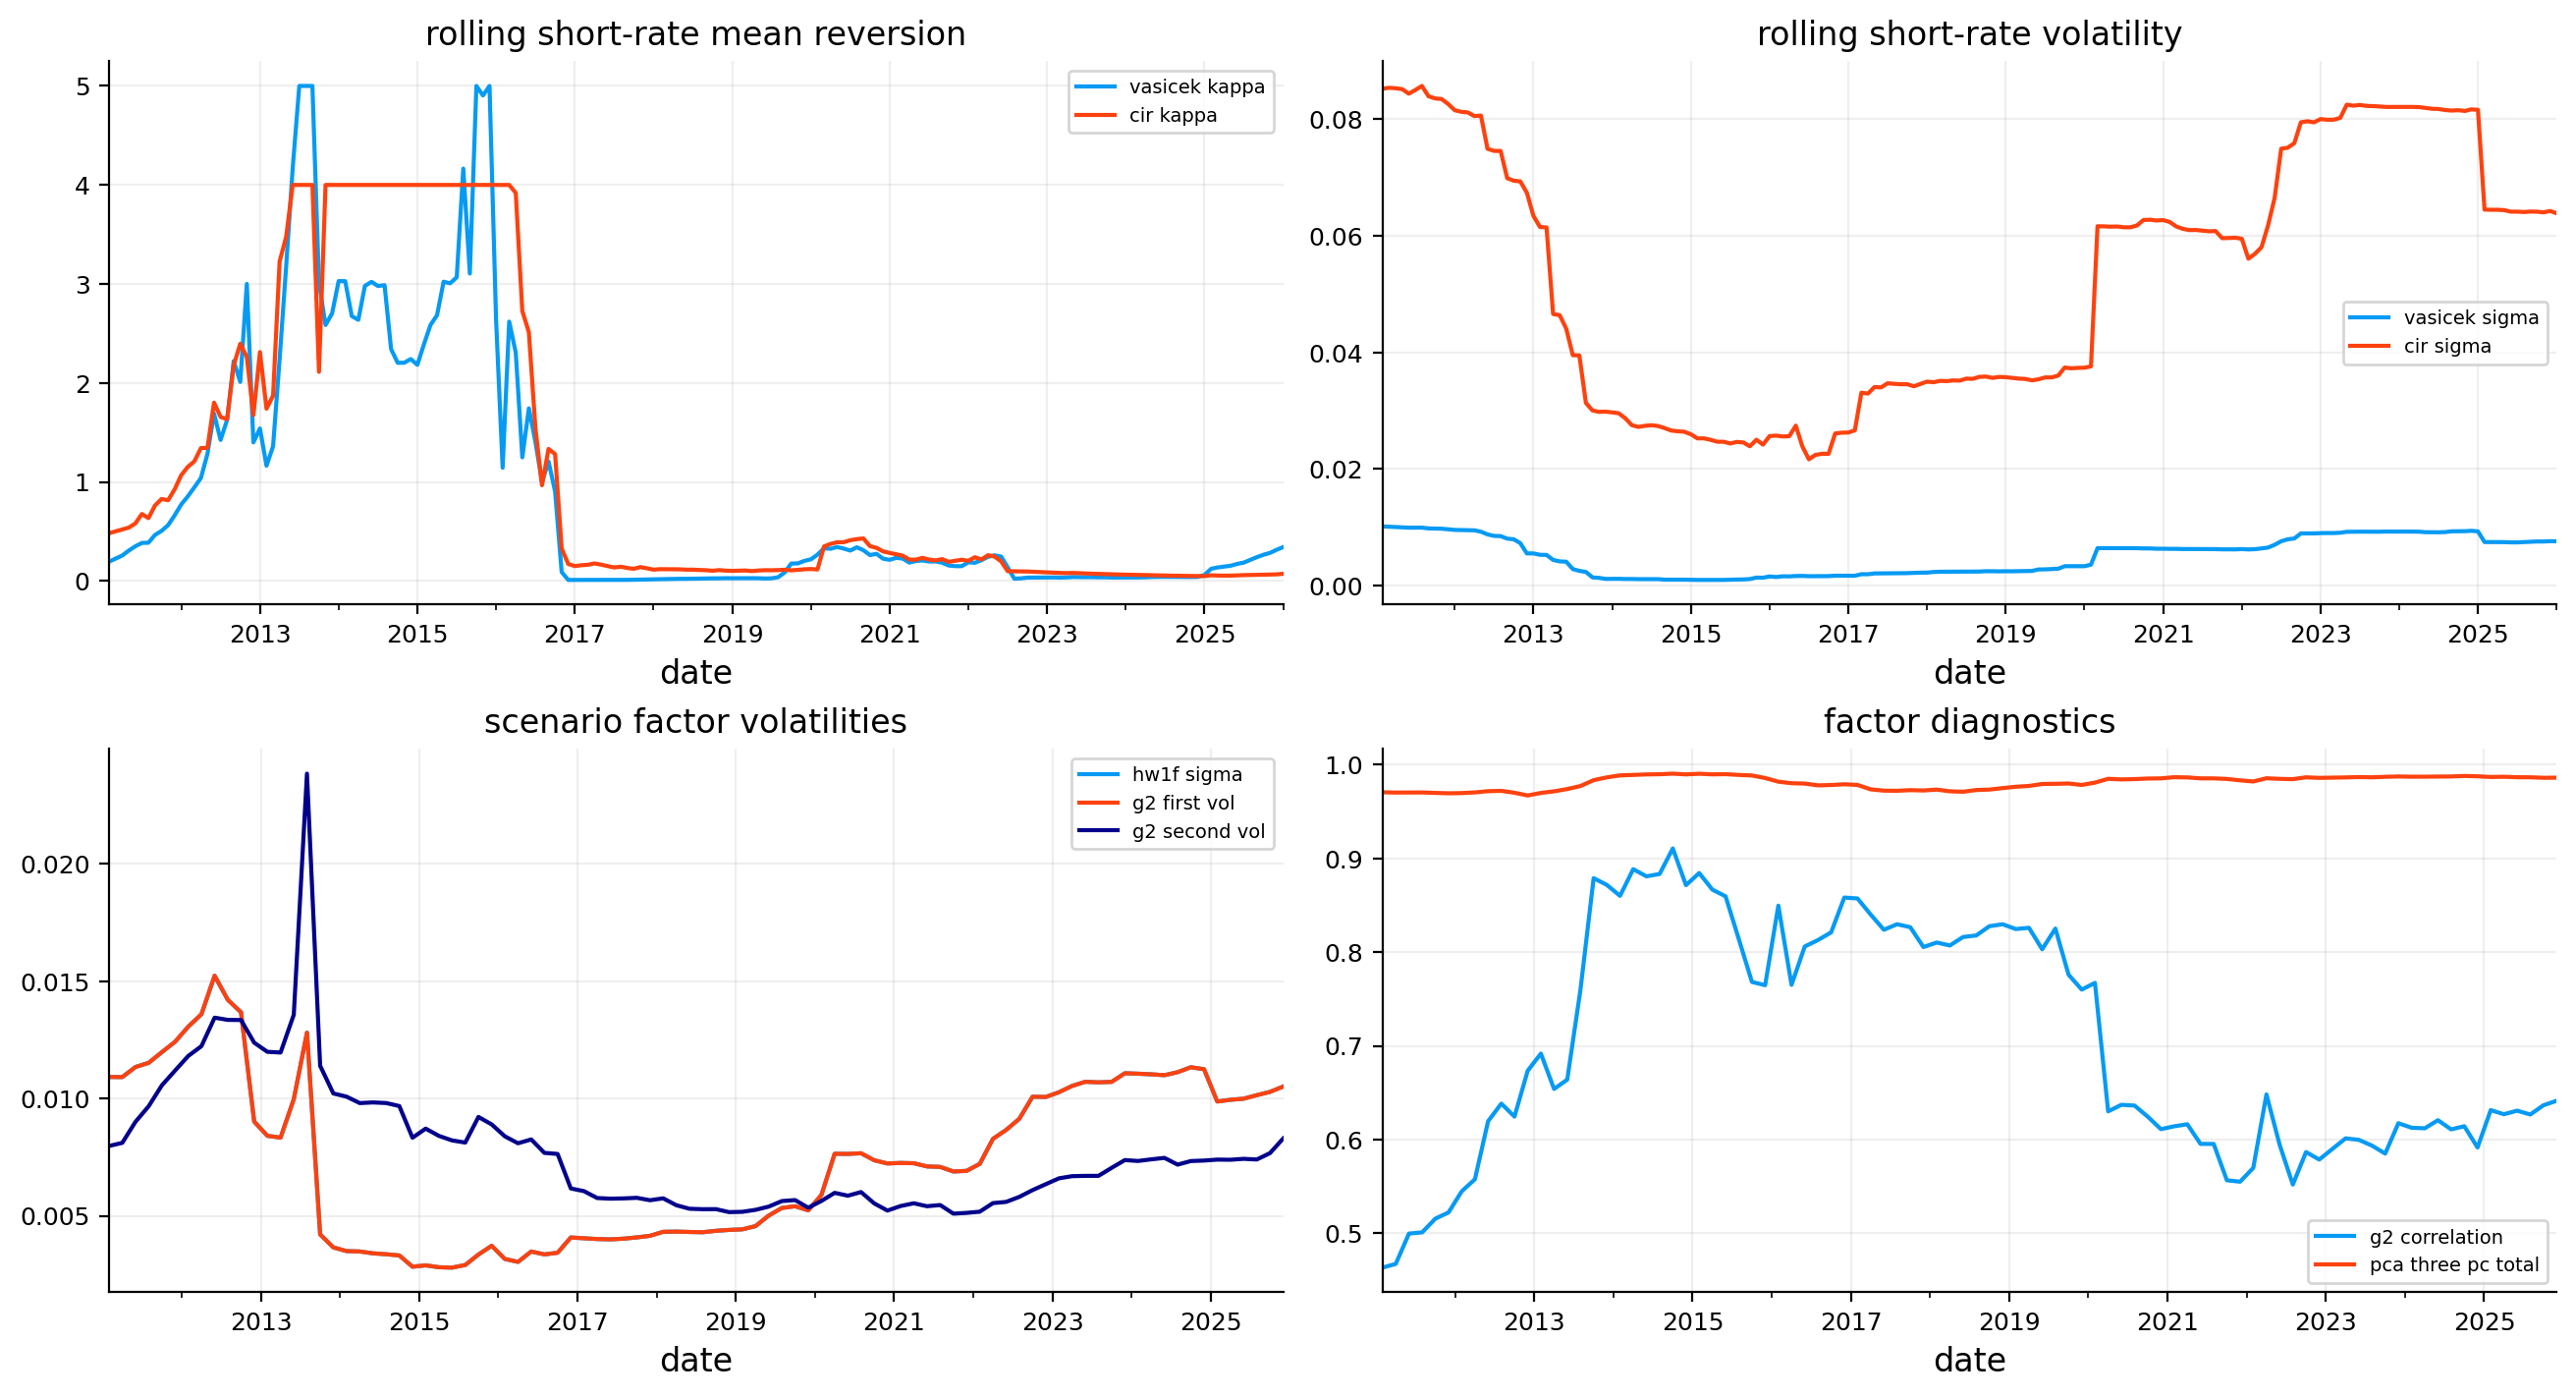

,metric,value
0,vasicek success rate,1.000000
1,cir success rate,1.000000
2,median vasicek residual acf1,0.143875
3,median cir residual acf1,-0.060870
4,median pca three pc explained,0.984549


In [47]:
stability_rows = []
for date in model_parameters.index[::2]:
    history = zero_rates.loc[:date].tail(rolling_window)
    hfit = estimate_hw1f(history, scenario_maturities)
    gfit = estimate_g2(history, scenario_maturities)
    pfit = estimate_pca(history, scenario_maturities, n_components=3)
    cov = gfit["factor covariance"]
    stability_rows.append({
        "date": date,
        "hw1f sigma": hfit["sigma monthly"] * np.sqrt(12),
        "hw1f mean reversion": hfit["a"],
        "g2 first vol": np.sqrt(cov[0, 0]) * np.sqrt(12),
        "g2 second vol": np.sqrt(cov[1, 1]) * np.sqrt(12),
        "g2 correlation": gfit["factor correlation"],
        "pca three pc total": pfit["explained"].sum(),
    })
scenario_parameters = pd.DataFrame(stability_rows).set_index("date")
fit_diagnostic_summary = pd.DataFrame({
    "metric": ["vasicek success rate", "cir success rate", "median vasicek residual acf1", "median cir residual acf1", "median pca three pc explained"],
    "value": [fit_diagnostics["vasicek success"].mean(), fit_diagnostics["cir success"].mean(), fit_diagnostics["vasicek residual acf1"].median(), fit_diagnostics["cir residual acf1"].median(), pca_parameters["three pc total"].median()],
})
fig, axes = plt.subplots(2, 2, figsize=(13, 7), constrained_layout=True)
model_parameters[["vasicek kappa", "cir kappa"]].plot(ax=axes[0, 0], title="rolling short-rate mean reversion")
model_parameters[["vasicek sigma", "cir sigma"]].plot(ax=axes[0, 1], title="rolling short-rate volatility")
scenario_parameters[["hw1f sigma", "g2 first vol", "g2 second vol"]].plot(ax=axes[1, 0], title="scenario factor volatilities")
scenario_parameters[["g2 correlation", "pca three pc total"]].plot(ax=axes[1, 1], title="factor diagnostics")
plt.show()
display(fit_diagnostic_summary)


,item,value
0,daily observations,13129
1,monthly dates,316
2,first monthly date,1999-09-30
3,last monthly date,2025-12-31


,ann_return,ann_vol,sharpe,sortino
object,,,,
dynamic duration ladder,0.006781,0.014251,0.481440,0.786256
fixed 5y ladder,0.003803,0.012488,0.310214,0.468615
jgb-implied swap overlay ladder,0.005711,0.014259,0.406555,0.640559


,ann_return,ann_vol,sharpe,sortino
object,,,,
dynamic duration ladder,0.002986,0.003281,0.910406,2.059546
jgb-implied swap overlay ladder,0.001921,0.002742,0.701457,1.226261


,months
selected model,
g2,123
hw1f,108


,months
target,
higher duration,118
neutral duration,113


strategy,dynamic,fixed 5y,jgb swap overlay
scenario,,,
parallel -100 bp,0.050154,0.050154,0.050154
parallel -50 bp,0.025077,0.025077,0.025077
parallel +50 bp,-0.025077,-0.025077,-0.025077
parallel +100 bp,-0.050154,-0.050154,-0.050154


,ann_return,ann_vol,sharpe,sortino,max_dd,selected
object,,,,,,
conservative overlay,0.001921,0.002742,0.701457,1.226261,-0.004279,True
stronger overlay,0.002561,0.003656,0.701427,1.226192,-0.005705,False


,item,value
0,first overlay return,2006-10-31
1,last overlay return,2025-12-31
2,active months,118
3,average abs notional,0.089464
4,average cost return,0.000007


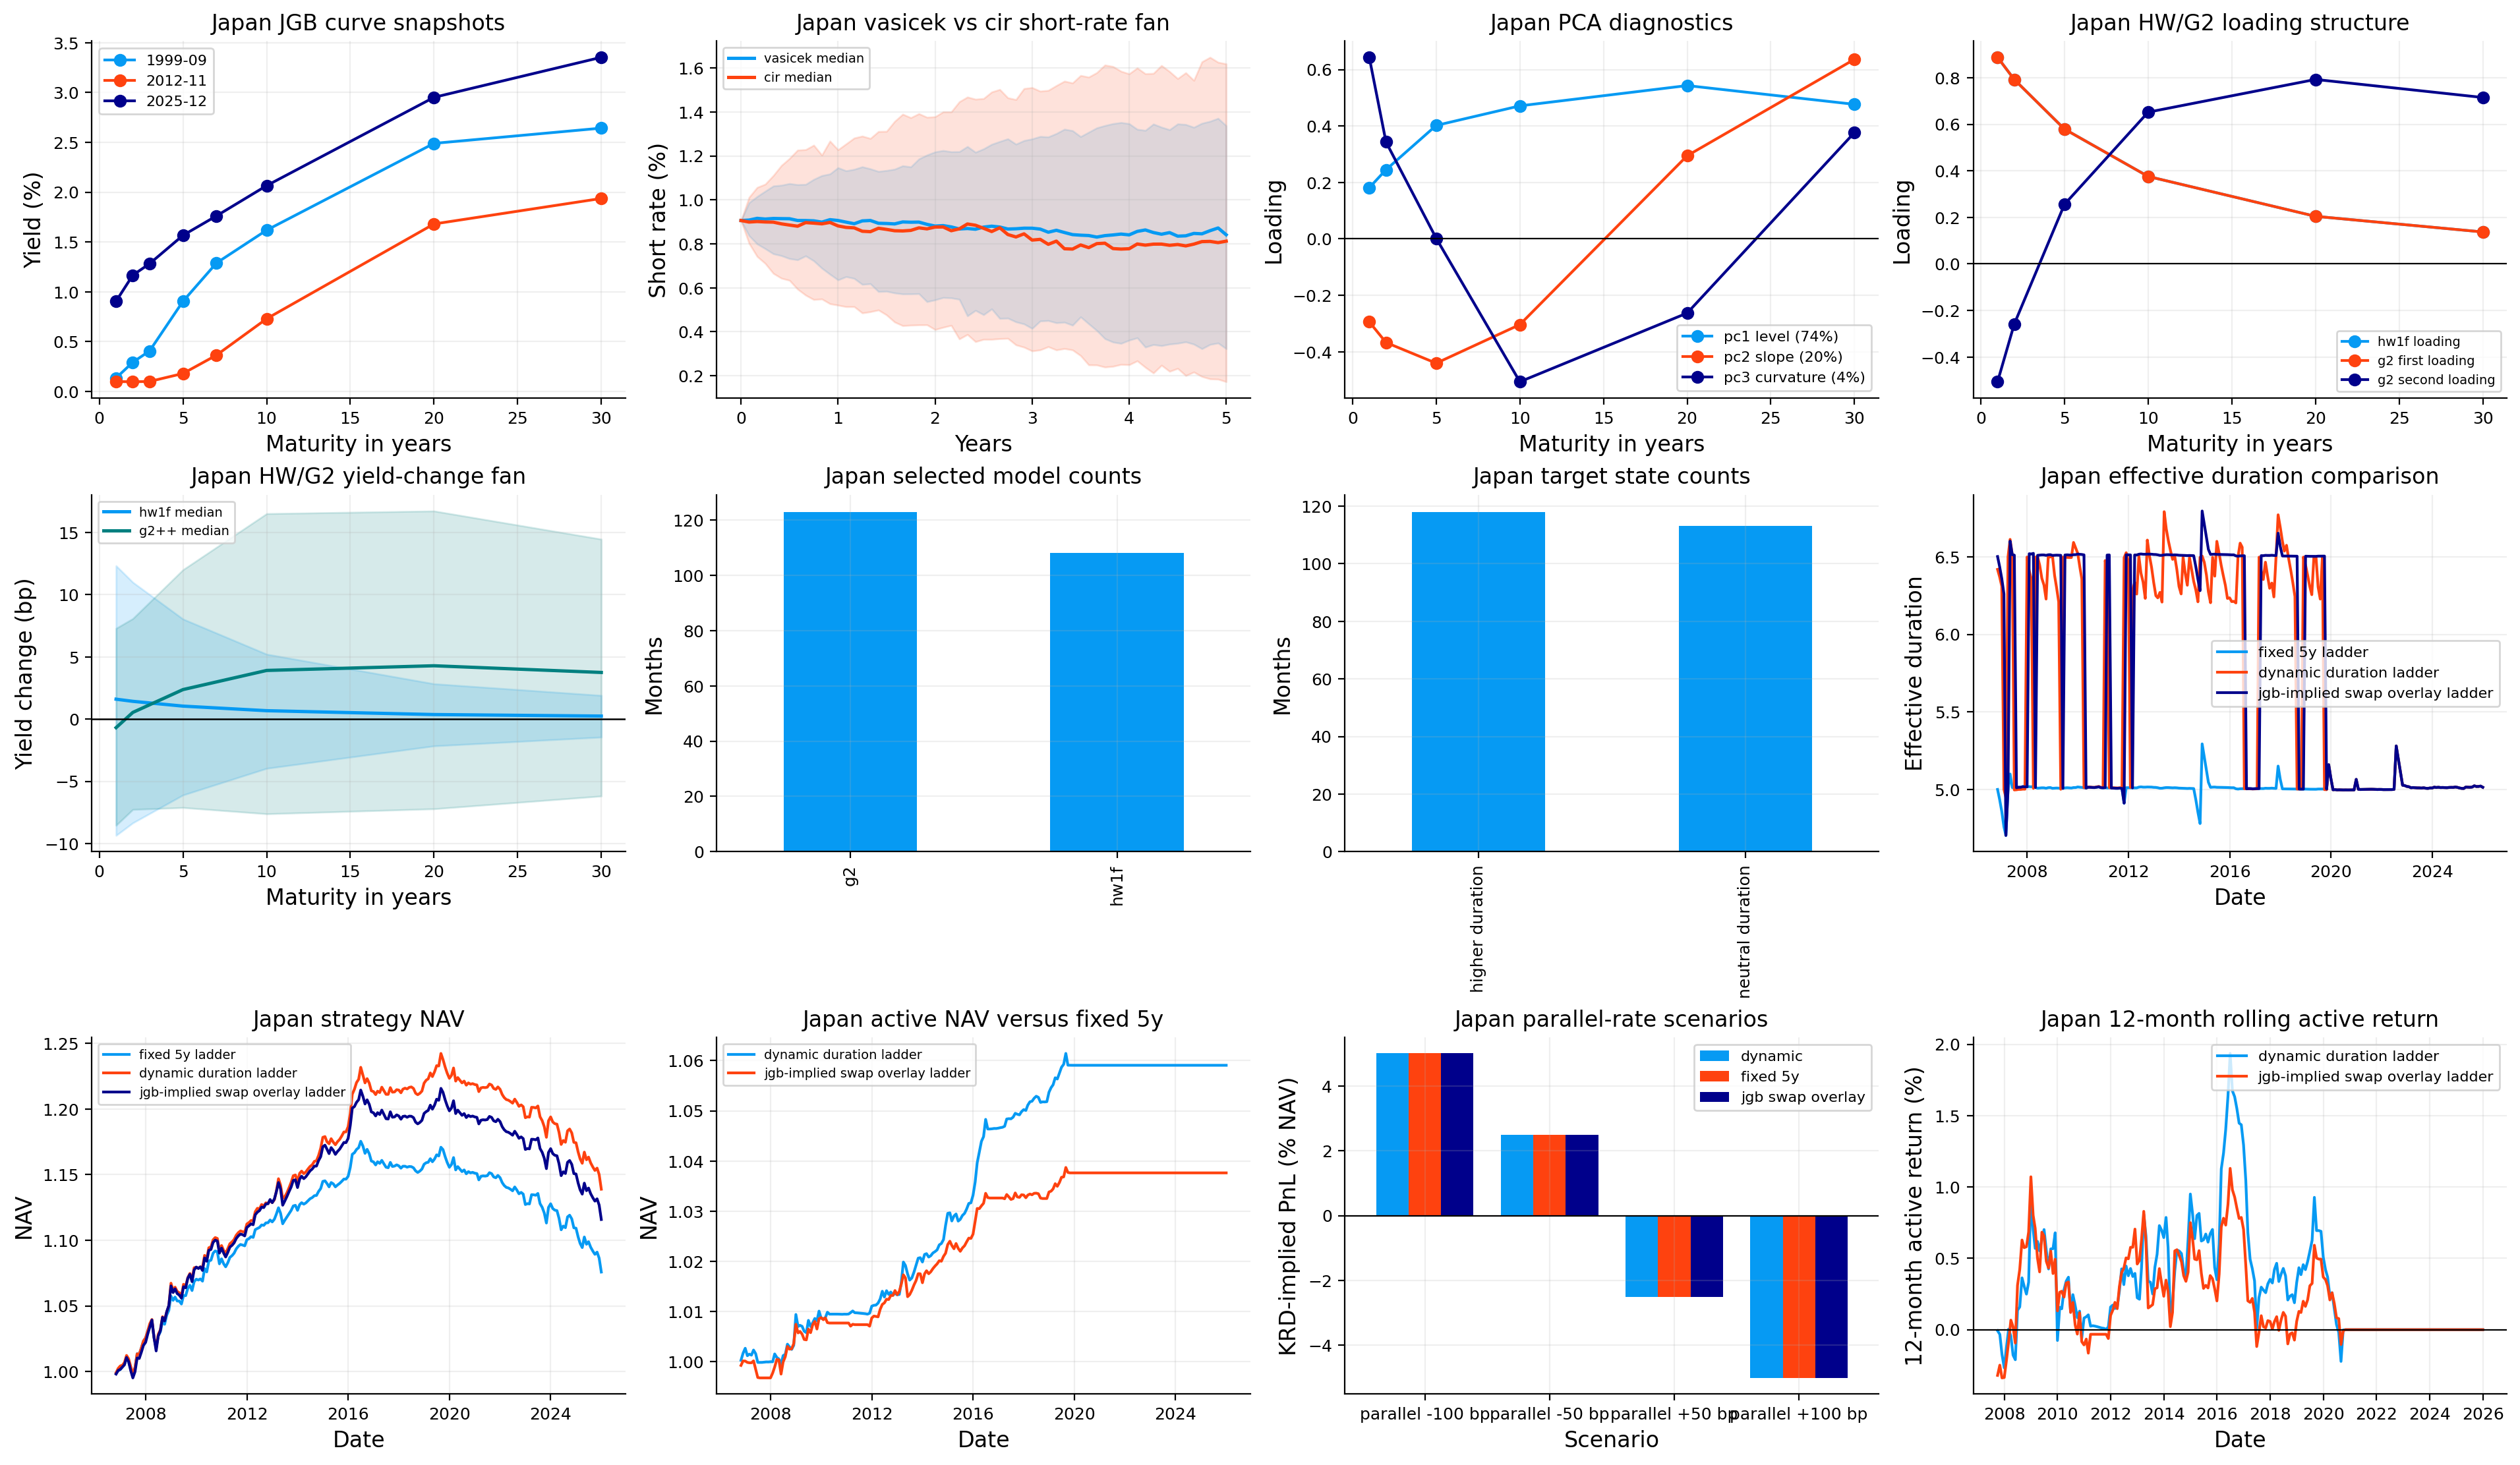

In [48]:
from functools import partial
from quantfinlab.backtest.fixed_income import combine_ladder_with_return_overlay, run_bond_ladder_backtest
from quantfinlab.dataio import load_par_yield_curve
from quantfinlab.fixed_income.ladder import active_returns_against_baseline, build_duration_reference_ladders, forward_carry_roll_panel, prepare_secondary_curve_market, select_dynamic_duration_targets, target_score_table
from quantfinlab.fixed_income.risk import krd_pivot
from quantfinlab.fixed_income.scenarios import parallel_shift_scenarios, strategy_scenario_summary
from quantfinlab.fixed_income.swaps import run_synthetic_swap_overlay
from quantfinlab.fixed_income.term_models import estimate_g2_style, estimate_hw1f, estimate_pca_curve, fit_cir, fit_vasicek_kalman, model_curve_view, simulate_cir_paths, simulate_g2_curves, simulate_hw1f_curves, simulate_vasicek_paths
from quantfinlab.plotting.fixed_income import plot_count_bar, plot_curve_snapshots, plot_hw_g2_loadings, plot_hw_g2_scenario_fan, plot_effective_duration_comparison, plot_ladder_nav, plot_pca_diagnostics, plot_rolling_active_return, plot_scenario_pnl_bars, plot_short_rate_fan_comparison
from quantfinlab.risk import drawdown_summary_table, nav_series, performance_table

jp_daily = load_par_yield_curve(root / "data" / "japan_yield_curve_all.csv", source="japan_mof").sort_index()
jp_selected_tenors = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]
jp_par_all, jp_zero_all, jp_dates_all = prepare_secondary_curve_market(jp_daily, selected_tenors=jp_selected_tenors, min_len=180)
jp_dates = jp_dates_all
jp_par = jp_par_all.loc[jp_dates]
jp_zero = jp_zero_all.loc[jp_dates]
jp_curve_years = np.array([1, 2, 3, 5, 7, 10, 20, 30], dtype=float)
jp_key_maturities = np.array([2.0, 5.0, 10.0, 30.0])
jp_scenario_maturities = np.array([1.0, 2.0, 5.0, 10.0, 20.0, 30.0])
jp_duration_targets = {"lower duration": 2.5, "neutral duration": 5.0, "higher duration": 6.5}
jp_duration_band = 0.30
jp_short_rate = jp_zero[1.0].rename("jgb short-rate proxy")
jp_vasicek_cols = [1.0, 2.0, 5.0, 10.0]
jp_vasicek_fit, jp_filtered = fit_vasicek_kalman(jp_zero[jp_vasicek_cols], np.array(jp_vasicek_cols))
jp_cir_fit = fit_cir(jp_short_rate)
jp_model_rows = []
for date in jp_dates[rolling_window:]:
    history = jp_zero.loc[:date].tail(rolling_window)
    vfit, _ = fit_vasicek_kalman(history[jp_vasicek_cols], np.array(jp_vasicek_cols))
    cfit = fit_cir(jp_short_rate.loc[history.index])
    jp_model_rows.append({"date": date, "vasicek kappa": vfit["kappa"], "vasicek theta": vfit["theta"], "vasicek sigma": vfit["sigma"], "vasicek success": vfit.get("optimizer success", False), "vasicek residual acf1": vfit.get("residual acf1", np.nan), "cir kappa": cfit["kappa"], "cir theta": cfit["theta"], "cir sigma": cfit["sigma"], "cir shift": cfit["shift"], "cir success": cfit.get("optimizer success", False), "cir residual acf1": cfit.get("residual acf1", np.nan)})
jp_model_parameters = pd.DataFrame(jp_model_rows).set_index("date")
jp_hw_fit = estimate_hw1f(jp_zero.tail(rolling_window), jp_scenario_maturities)
jp_g2_fit = estimate_g2_style(jp_zero.tail(rolling_window), jp_scenario_maturities)
jp_pca_fit = estimate_pca_curve(jp_zero.tail(rolling_window), jp_scenario_maturities)
jp_reference = build_duration_reference_ladders(jp_par, jp_duration_targets, buckets=ladder_buckets, target_weights=neutral_weights, trading_cost_bps=ladder_cost_bps, duration_band=jp_duration_band, tenor_cols=jp_selected_tenors, cash_tenor_label="1Y", min_block_len=120, risk_bucket_bounds=risk_bucket_bounds)
jp_baseline = jp_reference["neutral duration"]
jp_reference_carry = forward_carry_roll_panel(jp_reference, jp_par, jp_dates, buckets=ladder_buckets, tenor_cols=jp_selected_tenors, cash_tenor_label="1Y")
jp_reference_krd = {name: krd_pivot(result.diagnostics["krd"]).reindex(columns=ladder_buckets) for name, result in jp_reference.items()}

jp_model_view = partial(model_curve_view, zero_rates=jp_zero, short_rate=jp_short_rate, model_parameters=jp_model_parameters, scenario_maturities=jp_scenario_maturities, rolling_window=rolling_window)

jp_model_names = ["hw1f", "g2"]
jp_target_logs = {}
for model_name in jp_model_names:
    rows = []
    previous_target = "neutral duration"
    for date in jp_dates[rolling_window:-1]:
        scores = target_score_table(date, model_name, target_names=list(jp_duration_targets), duration_targets=jp_duration_targets, reference_krd=jp_reference_krd, reference_carry=jp_reference_carry, model_view_func=jp_model_view, key_maturities=jp_key_maturities, previous_target=previous_target)
        chosen = scores["score"].idxmax() if scores["expected active return"].max() > 0 else "neutral duration"
        row = scores.loc[chosen].to_dict()
        row.update({"date": date, "model": model_name, "target": chosen})
        rows.append(row)
        previous_target = chosen
    jp_target_logs[model_name] = pd.DataFrame(rows).set_index("date")
jp_model_target_by_date = pd.DataFrame({name: log["target duration"] for name, log in jp_target_logs.items()})
jp_model_results = {name: run_bond_ladder_backtest(jp_par, strategy_name=f"japan {name} dynamic duration ladder", buckets=ladder_buckets, target_weights=neutral_weights, trading_cost_bps=ladder_cost_bps, duration_target=5.0, duration_target_by_date=targets, duration_band=jp_duration_band, cash_tenor_label="1Y", min_block_len=120, tenor_cols=jp_selected_tenors, risk_bucket_bounds=risk_bucket_bounds) for name, targets in jp_model_target_by_date.items()}
jp_model_returns = pd.DataFrame({name: result.returns for name, result in jp_model_results.items()}).dropna(how="all")
jp_dynamic_log, jp_target_series = select_dynamic_duration_targets(jp_model_target_by_date, jp_model_returns, jp_baseline.returns, validation_months=24)
jp_dynamic_log["target"] = jp_dynamic_log["target duration"].map({v: k for k, v in jp_duration_targets.items()})
jp_dynamic = run_bond_ladder_backtest(jp_par, strategy_name="japan model-driven dynamic duration ladder", buckets=ladder_buckets, target_weights=neutral_weights, trading_cost_bps=ladder_cost_bps, duration_target=5.0, duration_target_by_date=jp_target_series, duration_band=jp_duration_band, cash_tenor_label="1Y", min_block_len=120, tenor_cols=jp_selected_tenors, risk_bucket_bounds=risk_bucket_bounds)
jp_first_return = jp_dates[jp_dates.get_loc(jp_dynamic_log.index.min()) + 1]
jp_eval_index = jp_dates[jp_dates >= jp_first_return]
jp_swap_log_strong, jp_swap_component_strong = run_synthetic_swap_overlay(jp_baseline, jp_zero, jp_dynamic_log, start_date=jp_first_return, label="JGB-implied synthetic swap overlay", duration_budget=2.0, dv01_fraction_cap=0.60, neutral_band=0.25)
jp_swap_result_strong = combine_ladder_with_return_overlay(jp_baseline, jp_swap_component_strong, strategy_name="5y ladder plus stronger JGB-implied synthetic swap overlay", overlay_costs=jp_swap_log_strong["cost return"] if not jp_swap_log_strong.empty else None, diagnostics={"overlay log": jp_swap_log_strong})
jp_swap_log_conservative, jp_swap_component_conservative = run_synthetic_swap_overlay(jp_baseline, jp_zero, jp_dynamic_log, start_date=jp_first_return, label="JGB-implied synthetic swap overlay")
jp_swap_result_conservative = combine_ladder_with_return_overlay(jp_baseline, jp_swap_component_conservative, strategy_name="5y ladder plus conservative JGB-implied synthetic swap overlay", overlay_costs=jp_swap_log_conservative["cost return"] if not jp_swap_log_conservative.empty else None, diagnostics={"overlay log": jp_swap_log_conservative})
jp_swap_candidate_returns = pd.concat({
    "stronger overlay": jp_swap_result_strong.returns,
    "conservative overlay": jp_swap_result_conservative.returns,
}, axis=1).reindex(jp_eval_index).dropna(how="all")
jp_swap_candidate_active = active_returns_against_baseline(jp_swap_candidate_returns, jp_baseline.returns.reindex(jp_swap_candidate_returns.index)).dropna(how="all")
jp_swap_candidate_perf = performance_table(jp_swap_candidate_active, annualization=12)
jp_swap_candidate_dd = drawdown_summary_table(jp_swap_candidate_active)[["max_dd"]]
use_stronger_overlay = bool(
    jp_swap_candidate_perf.loc["stronger overlay", "ann_return"] >= jp_swap_candidate_perf.loc["conservative overlay", "ann_return"]
    and jp_swap_candidate_dd.loc["stronger overlay", "max_dd"] >= jp_swap_candidate_dd.loc["conservative overlay", "max_dd"]
)
jp_swap_log = jp_swap_log_strong if use_stronger_overlay else jp_swap_log_conservative
jp_swap_result = jp_swap_result_strong if use_stronger_overlay else jp_swap_result_conservative
jp_swap_component = jp_swap_component_strong if use_stronger_overlay else jp_swap_component_conservative
jp_overlay_setting_table = jp_swap_candidate_perf.join(jp_swap_candidate_dd)
jp_overlay_setting_table["selected"] = pd.Series({"stronger overlay": use_stronger_overlay, "conservative overlay": not use_stronger_overlay})
jp_returns = pd.concat([jp_baseline.returns.rename("fixed 5y ladder"), jp_dynamic.returns.rename("dynamic duration ladder"), jp_swap_result.returns.rename("jgb-implied swap overlay ladder")], axis=1).reindex(jp_eval_index).dropna(how="all")
jp_active_returns = active_returns_against_baseline(jp_returns[["dynamic duration ladder", "jgb-implied swap overlay ladder"]], jp_returns["fixed 5y ladder"]).dropna(how="all")
jp_perf = performance_table(jp_returns, annualization=12)
jp_active_perf = performance_table(jp_active_returns, annualization=12)
jp_model_counts = jp_dynamic_log["selected model"].value_counts().to_frame("months")
jp_target_counts = jp_dynamic_log["target"].value_counts().to_frame("months")
jp_latest = jp_returns.index.max()
jp_base_krd = krd_pivot(jp_baseline.diagnostics["krd"]).reindex(columns=ladder_buckets).loc[:jp_latest].iloc[-1]
jp_dyn_krd = krd_pivot(jp_dynamic.diagnostics["krd"]).reindex(columns=ladder_buckets).loc[:jp_latest].iloc[-1]
jp_overlay_krd = jp_base_krd.copy()
if not jp_swap_log.empty:
    jp_overlay_krd.loc[10] = jp_overlay_krd.loc[10] + jp_swap_log["overlay pv01"].dropna().iloc[-1] / 1e-4
jp_shocks = parallel_shift_scenarios([-100, -50, 50, 100], maturities=ladder_buckets)
jp_scenario_summary = strategy_scenario_summary({"fixed 5y": jp_base_krd, "dynamic": jp_dyn_krd, "jgb swap overlay": jp_overlay_krd}, jp_shocks)
jp_swap_summary = pd.DataFrame({"item": ["first overlay return", "last overlay return", "active months", "average abs notional", "average cost return"], "value": [jp_swap_log.index.min().date() if not jp_swap_log.empty else None, jp_swap_log.index.max().date() if not jp_swap_log.empty else None, int((jp_swap_log["side"] != "flat").sum()) if not jp_swap_log.empty else 0, jp_swap_log["notional"].abs().mean() if not jp_swap_log.empty else 0.0, jp_swap_log["cost return"].mean() if not jp_swap_log.empty else 0.0]})
display(pd.DataFrame({"item": ["daily observations", "monthly dates", "first monthly date", "last monthly date"], "value": [len(jp_daily), len(jp_dates), jp_dates.min().date(), jp_dates.max().date()]}))
display(jp_perf)
display(jp_active_perf)
display(jp_model_counts)
display(jp_target_counts)
display(jp_scenario_summary)
display(jp_overlay_setting_table)
display(jp_swap_summary)
jp_vpaths = simulate_vasicek_paths(jp_short_rate.iloc[-1], jp_vasicek_fit, years=5, n_paths=250, seed=91)
jp_cpaths = simulate_cir_paths(jp_short_rate.iloc[-1], jp_cir_fit, years=5, n_paths=250, seed=92)
jp_base_curve = jp_zero.loc[jp_dates[-1], jp_scenario_maturities].to_numpy(float)
jp_hw_curves = simulate_hw1f_curves(jp_base_curve, jp_hw_fit, n_scenarios=1200, seed=93)
jp_g2_curves = simulate_g2_curves(jp_base_curve, jp_g2_fit, n_scenarios=1200, seed=94)
fig, axes = plt.subplots(3, 4, figsize=(19, 11), constrained_layout=True)
flat_axes = axes.ravel()
jp_snapshot_dates = [jp_dates[0], jp_dates[len(jp_dates) // 2], jp_dates[-1]]
jp_navs = pd.DataFrame({col: nav_series(jp_returns[col].dropna(), start_value=1) for col in jp_returns.columns})
jp_active_navs = pd.DataFrame({col: nav_series(jp_active_returns[col].dropna(), start_value=1) for col in jp_active_returns.columns})
jp_base_duration = jp_baseline.diagnostics["risk"]["effective_duration"]
jp_dynamic_duration = jp_dynamic.diagnostics["risk"]["effective_duration"]
jp_overlay_duration_add = (jp_swap_log["overlay pv01"] / (jp_swap_log["nav start"] * 1e-4)).replace([np.inf, -np.inf], np.nan)
jp_swap_implied_duration = jp_base_duration.reindex(jp_swap_log.index).ffill() + jp_overlay_duration_add
jp_duration_comparison = pd.concat([
    jp_base_duration.rename("fixed 5y ladder"),
    jp_dynamic_duration.rename("dynamic duration ladder"),
    jp_swap_implied_duration.rename("jgb-implied swap overlay ladder"),
], axis=1).reindex(jp_returns.index).ffill()
plot_curve_snapshots(flat_axes[0], jp_par, jp_curve_years, jp_snapshot_dates, tenor_cols=jp_selected_tenors, title="Japan JGB curve snapshots")
plot_short_rate_fan_comparison(flat_axes[1], jp_vpaths, jp_cpaths, title="Japan vasicek vs cir short-rate fan")
plot_pca_diagnostics(flat_axes[2], jp_scenario_maturities, jp_pca_fit, title="Japan PCA diagnostics")
plot_hw_g2_loadings(flat_axes[3], jp_scenario_maturities, jp_hw_fit, jp_g2_fit, title="Japan HW/G2 loading structure")
plot_hw_g2_scenario_fan(flat_axes[4], jp_scenario_maturities, jp_base_curve, jp_hw_curves, jp_g2_curves, title="Japan HW/G2 yield-change fan")
plot_count_bar(flat_axes[5], jp_model_counts, title="Japan selected model counts")
plot_count_bar(flat_axes[6], jp_target_counts, title="Japan target state counts")
plot_effective_duration_comparison(flat_axes[7], jp_duration_comparison, title="Japan effective duration comparison")
plot_ladder_nav(flat_axes[8], jp_navs, title="Japan strategy NAV")
plot_ladder_nav(flat_axes[9], jp_active_navs, title="Japan active NAV versus fixed 5y")
plot_scenario_pnl_bars(flat_axes[10], jp_scenario_summary, title="Japan parallel-rate scenarios")
plot_rolling_active_return(flat_axes[11], jp_active_returns, window=12, title="Japan 12-month rolling active return")
plt.show()
